# 16_model_training_risk_modules.ipynb — Modelos de riesgo marítimo

Notebook para Mac. Entrena y compara módulos de riesgo a partir de:

```text
gold/multitarget_training_dataset/
```

Módulos:

```text
risk_general
risk_beach
risk_navigation
```

Horizontes:

```text
+3h, +6h, +12h, +24h, +48h
```

Modelos:

```text
PersistenceRisk
LightGBMClassifier
XGBClassifier, si está instalado
PhysicalDerivedRisk, si existen predicciones del notebook 15
```

Salidas:

```text
models/risk_modules/
gold/model_results/risk_modules/
```

## Celda 0 — Entorno

In [1]:
import sys

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("Entorno local/Mac detectado. No se monta Google Drive.")

Entorno local/Mac detectado. No se monta Google Drive.


## Celda 1 — Dependencias

In [2]:
import sys

if "google.colab" in sys.modules:
    !pip -q install lightgbm xgboost pandas numpy pyarrow scikit-learn matplotlib joblib psutil tqdm
else:
    print("Si falta algo, instala en tu .venv:")
    print("pip install lightgbm xgboost pandas numpy pyarrow scikit-learn matplotlib joblib psutil tqdm")

Si falta algo, instala en tu .venv:
pip install lightgbm xgboost pandas numpy pyarrow scikit-learn matplotlib joblib psutil tqdm


## Celda 2 — Imports, rutas y configuración

In [3]:
from pathlib import Path
import os, sys, json, gc, platform, warnings, joblib
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

try:
    import psutil
except Exception:
    psutil = None

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
except Exception as e:
    raise ImportError("No se pudo importar LightGBM. Ejecuta: pip install lightgbm") from e

try:
    import xgboost as xgb
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    xgb = None
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# RUTAS MAC
# ------------------------------------------------------------------
# El notebook está en deep-wave-canarias/notebooks/
# Los datos están en deep-wave-canarias/gold/multitarget_training_dataset/
LOCAL_BASE_DIR = Path.cwd().parent
LOCAL_INPUT_GOLD_DIR = None

RUNNING_IN_COLAB = "google.colab" in sys.modules

def resolve_paths():
    if RUNNING_IN_COLAB:
        base_dir = Path("/content/drive/MyDrive/AI Projects/DeepWave Canarias")
        return base_dir, base_dir / "gold" / "multitarget_training_dataset"

    if LOCAL_INPUT_GOLD_DIR is not None:
        input_dir = Path(LOCAL_INPUT_GOLD_DIR).expanduser().resolve()
        if not input_dir.exists():
            raise FileNotFoundError(f"LOCAL_INPUT_GOLD_DIR no existe: {input_dir}")
        return input_dir.parent.parent, input_dir

    base_dir = Path(LOCAL_BASE_DIR).expanduser().resolve()
    return base_dir, base_dir / "gold" / "multitarget_training_dataset"

BASE_DIR, INPUT_GOLD_DIR = resolve_paths()
GOLD_DIR = BASE_DIR / "gold"
MODELS_DIR = BASE_DIR / "models" / "risk_modules"
RESULTS_DIR = GOLD_DIR / "model_results" / "risk_modules"
PHYSICAL_RESULTS_DIR = GOLD_DIR / "model_results" / "multitarget_physical"
REPORT_DIR = GOLD_DIR / "_quality_reports"
META_DIR = GOLD_DIR / "_metadata"

for d in [MODELS_DIR, RESULTS_DIR, REPORT_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if not INPUT_GOLD_DIR.exists():
    raise FileNotFoundError(
        "No existe gold/multitarget_training_dataset/. Ejecuta primero el notebook 14.\\n"
        f"Ruta esperada: {INPUT_GOLD_DIR}"
    )

# ------------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------------
HORIZONS_HOURS = [3, 6, 12, 24, 48]
RISK_MODULES = ["general", "beach", "navigation"]
RISK_CLASSES = [0, 1, 2, 3]
RISK_CLASS_NAMES = {0: "low", 1: "moderate", 2: "high", 3: "extreme"}

N_JOBS = -1
RANDOM_STATE = 42
USE_ZONA_ID_AS_FEATURE = True

# En Mac potente puedes dejar None.
MAX_TRAIN_ROWS_PER_MODEL = None
MAX_VAL_ROWS_PER_MODEL = None
MAX_TEST_ROWS_PER_MODEL = None

MAX_MISSING_PCT_FEATURE = 98.5
MAX_FEATURES = None

# XGBoost puede tardar mucho. Se entrena si está instalado.
TRAIN_XGBOOST = True

# Pesos extra para clases peligrosas.
DANGER_CLASS_MULTIPLIERS = {0: 1.00, 1: 1.15, 2: 2.00, 3: 3.00}

# LightGBM
LGBM_N_ESTIMATORS = 3500
LGBM_LEARNING_RATE = 0.025
LGBM_EARLY_STOPPING_ROUNDS = 150

# XGBoost
XGB_N_ESTIMATORS = 1800
XGB_LEARNING_RATE = 0.035
XGB_EARLY_STOPPING_ROUNDS = 100

# Comparación adicional usando predicciones físicas del notebook 15 si existen.
EVALUATE_PHYSICAL_DERIVED_RISK = True

SAVE_PREDICTIONS = True
PREDICTION_SAMPLE_LIMIT = None

SENTINEL_VALUES = [-9999, -9999.0, -9999.9, -99999, -99999.0, -1e20, 1e20]

RISK_THRESHOLDS = {
    "general": {"moderate_hs": 1.0, "high_hs": 2.0, "extreme_hs": 3.0},
    "beach": {"moderate_hs": 1.0, "high_hs": 1.8, "extreme_hs": 2.7, "high_period": 12.0, "strong_wind": 10.0},
    "navigation": {"moderate_hs": 1.2, "high_hs": 2.0, "extreme_hs": 3.0, "strong_wind": 10.0, "very_strong_wind": 14.0, "long_period": 11.0},
}

print("Sistema:", platform.platform())
print("BASE_DIR:", BASE_DIR)
print("INPUT_GOLD_DIR:", INPUT_GOLD_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("LightGBM:", lgb.__version__)
print("XGBoost disponible:", XGBOOST_AVAILABLE)
if XGBOOST_AVAILABLE:
    print("XGBoost:", xgb.__version__)
print("TRAIN_XGBOOST efectivo:", TRAIN_XGBOOST and XGBOOST_AVAILABLE)

if psutil is not None:
    mem = psutil.virtual_memory()
    print(f"RAM total: {mem.total / 1024**3:.1f} GB")
    print(f"RAM disponible: {mem.available / 1024**3:.1f} GB")

Sistema: macOS-26.3.1-arm64-arm-64bit
BASE_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias
INPUT_GOLD_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/multitarget_training_dataset
MODELS_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/models/risk_modules
RESULTS_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/risk_modules
LightGBM: 4.6.0
XGBoost disponible: False
TRAIN_XGBOOST efectivo: False
RAM total: 16.0 GB
RAM disponible: 2.7 GB


## Celda 3 — Funciones auxiliares

In [4]:
def ensure_utc(series):
    return pd.to_datetime(series, utc=True, errors="coerce")

def memory_report(name, df):
    mb = df.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"{name}: shape={df.shape}, memoria≈{mb:.1f} MB")

def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)

def sample_df(df, max_rows, random_state=RANDOM_STATE):
    if max_rows is None or len(df) <= max_rows:
        return df
    return df.sample(n=max_rows, random_state=random_state).sort_index()

def clean_sentinel_values(df):
    numeric_cols = df.select_dtypes(include=[np.number, "boolean"]).columns.tolist()
    for c in tqdm(numeric_cols, desc="Limpiando sentinelas"):
        if pd.api.types.is_bool_dtype(df[c]):
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce").replace(SENTINEL_VALUES, np.nan)
    return df

def assign_risk_general(hs):
    hs = pd.to_numeric(hs, errors="coerce")
    risk = pd.Series(np.nan, index=hs.index, dtype="float64")
    risk.loc[hs < RISK_THRESHOLDS["general"]["moderate_hs"]] = 0
    risk.loc[(hs >= RISK_THRESHOLDS["general"]["moderate_hs"]) & (hs < RISK_THRESHOLDS["general"]["high_hs"])] = 1
    risk.loc[(hs >= RISK_THRESHOLDS["general"]["high_hs"]) & (hs < RISK_THRESHOLDS["general"]["extreme_hs"])] = 2
    risk.loc[hs >= RISK_THRESHOLDS["general"]["extreme_hs"]] = 3
    return risk.astype("Int16")

def assign_risk_beach(hs, period=None, wind_speed=None, exposure=None):
    hs = pd.to_numeric(hs, errors="coerce")
    period = pd.to_numeric(period, errors="coerce") if period is not None else pd.Series(np.nan, index=hs.index)
    wind_speed = pd.to_numeric(wind_speed, errors="coerce") if wind_speed is not None else pd.Series(np.nan, index=hs.index)
    exposure = pd.to_numeric(exposure, errors="coerce") if exposure is not None else pd.Series(0, index=hs.index)

    risk = pd.Series(np.nan, index=hs.index, dtype="float64")
    risk.loc[hs < RISK_THRESHOLDS["beach"]["moderate_hs"]] = 0
    risk.loc[(hs >= RISK_THRESHOLDS["beach"]["moderate_hs"]) & (hs < RISK_THRESHOLDS["beach"]["high_hs"])] = 1
    risk.loc[(hs >= RISK_THRESHOLDS["beach"]["high_hs"]) & (hs < RISK_THRESHOLDS["beach"]["extreme_hs"])] = 2
    risk.loc[hs >= RISK_THRESHOLDS["beach"]["extreme_hs"]] = 3

    boost_period = (period >= RISK_THRESHOLDS["beach"]["high_period"]) & (hs >= 1.2)
    boost_wind = wind_speed >= RISK_THRESHOLDS["beach"]["strong_wind"]
    boost_exposure = (exposure >= 1) & (hs >= 1.0)

    boost = boost_period.astype("float64").fillna(0) + boost_wind.astype("float64").fillna(0) + boost_exposure.astype("float64").fillna(0)
    risk = risk + np.where(boost >= 2, 1, 0)
    return risk.clip(0, 3).astype("Int16")

def assign_risk_navigation(hs, period=None, wind_speed=None):
    hs = pd.to_numeric(hs, errors="coerce")
    period = pd.to_numeric(period, errors="coerce") if period is not None else pd.Series(np.nan, index=hs.index)
    wind_speed = pd.to_numeric(wind_speed, errors="coerce") if wind_speed is not None else pd.Series(np.nan, index=hs.index)

    risk = pd.Series(np.nan, index=hs.index, dtype="float64")
    risk.loc[hs < RISK_THRESHOLDS["navigation"]["moderate_hs"]] = 0
    risk.loc[(hs >= RISK_THRESHOLDS["navigation"]["moderate_hs"]) & (hs < RISK_THRESHOLDS["navigation"]["high_hs"])] = 1
    risk.loc[(hs >= RISK_THRESHOLDS["navigation"]["high_hs"]) & (hs < RISK_THRESHOLDS["navigation"]["extreme_hs"])] = 2
    risk.loc[hs >= RISK_THRESHOLDS["navigation"]["extreme_hs"]] = 3

    wind_boost_1 = wind_speed >= RISK_THRESHOLDS["navigation"]["strong_wind"]
    wind_boost_2 = wind_speed >= RISK_THRESHOLDS["navigation"]["very_strong_wind"]
    period_boost = (period >= RISK_THRESHOLDS["navigation"]["long_period"]) & (hs >= 1.5)

    risk = risk + wind_boost_1.astype("float64").fillna(0)
    risk = risk + wind_boost_2.astype("float64").fillna(0)
    risk = risk + period_boost.astype("float64").fillna(0)
    return risk.clip(0, 3).astype("Int16")

def assign_risk_by_module(module, hs, period=None, wind_speed=None, exposure=None):
    if module == "general":
        return assign_risk_general(hs)
    if module == "beach":
        return assign_risk_beach(hs, period=period, wind_speed=wind_speed, exposure=exposure)
    if module == "navigation":
        return assign_risk_navigation(hs, period=period, wind_speed=wind_speed)
    raise ValueError(f"Módulo desconocido: {module}")

def classification_metrics(y_true, y_pred):
    y_true = pd.Series(y_true, dtype="Int64")
    y_pred = pd.Series(y_pred, dtype="Int64")
    mask = y_true.notna() & y_pred.notna()

    out = {"n": int(mask.sum()), "accuracy": np.nan, "balanced_accuracy": np.nan, "macro_f1": np.nan, "weighted_f1": np.nan}
    for cls in RISK_CLASSES:
        out[f"precision_class_{cls}"] = np.nan
        out[f"recall_class_{cls}"] = np.nan
        out[f"f1_class_{cls}"] = np.nan
        out[f"support_class_{cls}"] = 0

    if mask.sum() == 0:
        return out

    yt = y_true[mask].astype(int).values
    yp = y_pred[mask].astype(int).values

    out["accuracy"] = float(accuracy_score(yt, yp))
    out["balanced_accuracy"] = float(balanced_accuracy_score(yt, yp))
    out["macro_f1"] = float(f1_score(yt, yp, labels=RISK_CLASSES, average="macro", zero_division=0))
    out["weighted_f1"] = float(f1_score(yt, yp, labels=RISK_CLASSES, average="weighted", zero_division=0))

    precision, recall, f1, support = precision_recall_fscore_support(yt, yp, labels=RISK_CLASSES, zero_division=0)
    for i, cls in enumerate(RISK_CLASSES):
        out[f"precision_class_{cls}"] = float(precision[i])
        out[f"recall_class_{cls}"] = float(recall[i])
        out[f"f1_class_{cls}"] = float(f1[i])
        out[f"support_class_{cls}"] = int(support[i])
    return out

def class_distribution(series):
    s = pd.Series(series).dropna().astype(int)
    counts = s.value_counts().reindex(RISK_CLASSES, fill_value=0)
    total = counts.sum()
    out = {}
    for k, v in counts.items():
        out[f"class_{k}"] = int(v)
        out[f"class_{k}_pct"] = float(v / total * 100) if total else np.nan
    return out

def make_sample_weights(y):
    y = pd.Series(y).astype(int)
    counts = y.value_counts().reindex(RISK_CLASSES, fill_value=0)
    n = len(y)
    k = len(RISK_CLASSES)
    weights_by_class = {}
    for cls in RISK_CLASSES:
        if counts.loc[cls] == 0:
            weights_by_class[cls] = 0.0
        else:
            balanced = n / (k * counts.loc[cls])
            weights_by_class[cls] = balanced * DANGER_CLASS_MULTIPLIERS.get(cls, 1.0)
    return y.map(weights_by_class).astype("float32").values, weights_by_class

def model_safe_name(name):
    return str(name).replace("/", "_").replace(" ", "_").replace(":", "_")

def make_model_dir(module, horizon):
    d = MODELS_DIR / model_safe_name(module) / f"horizon_{horizon}h"
    d.mkdir(parents=True, exist_ok=True)
    return d

def build_lgbm_classifier(module, horizon):
    return LGBMClassifier(
        objective="multiclass",
        num_class=len(RISK_CLASSES),
        n_estimators=LGBM_N_ESTIMATORS,
        learning_rate=LGBM_LEARNING_RATE,
        num_leaves=96,
        max_depth=-1,
        min_child_samples=60,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=0.20,
        random_state=RANDOM_STATE + int(horizon),
        n_jobs=N_JOBS,
        importance_type="gain",
        verbosity=-1,
    )

def fit_lgbm_classifier(model, X_train, y_train, X_val, y_val, sample_weight):
    callbacks = [
        lgb.early_stopping(LGBM_EARLY_STOPPING_ROUNDS, verbose=False),
        lgb.log_evaluation(period=250),
    ]
    model.fit(
        X_train, y_train,
        sample_weight=sample_weight,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
        callbacks=callbacks,
    )
    return model

def build_xgb_classifier(module, horizon):
    return XGBClassifier(
        objective="multi:softprob",
        num_class=len(RISK_CLASSES),
        n_estimators=XGB_N_ESTIMATORS,
        learning_rate=XGB_LEARNING_RATE,
        max_depth=7,
        min_child_weight=10,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=0.75,
        random_state=RANDOM_STATE + int(horizon),
        n_jobs=N_JOBS,
        tree_method="hist",
        eval_metric="mlogloss",
    )

def fit_xgb_classifier(model, X_train, y_train, X_val, y_val, sample_weight):
    try:
        model.fit(
            X_train, y_train,
            sample_weight=sample_weight,
            eval_set=[(X_val, y_val)],
            verbose=False,
            early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
        )
    except TypeError:
        model.fit(
            X_train, y_train,
            sample_weight=sample_weight,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )
    return model

def get_current_physical_for_risk(df):
    hs_col = "simar_hs" if "simar_hs" in df.columns else "hs"
    tp_col = "simar_tp" if "simar_tp" in df.columns else ("simar_tm02" if "simar_tm02" in df.columns else None)
    wind_col = "simar_wind_speed" if "simar_wind_speed" in df.columns else "wind_speed"
    exposure_col = "coast_exposure_score" if "coast_exposure_score" in df.columns else None

    hs = df[hs_col] if hs_col in df.columns else pd.Series(np.nan, index=df.index)
    period = df[tp_col] if tp_col is not None and tp_col in df.columns else None
    wind = df[wind_col] if wind_col in df.columns else None
    exposure = df[exposure_col] if exposure_col is not None and exposure_col in df.columns else None
    return hs, period, wind, exposure

## Celda 4 — Cargar Gold multitarget

In [5]:
dataset = ds.dataset(str(INPUT_GOLD_DIR), format="parquet", partitioning="hive")
gold = dataset.to_table().to_pandas()

gold["timestamp"] = ensure_utc(gold["timestamp"])
gold["split"] = gold["split"].astype(str)
gold["zona_id"] = gold["zona_id"].astype(str)

if "isla" in gold.columns:
    gold["isla"] = gold["isla"].astype("string").fillna("UNKNOWN")
else:
    gold["isla"] = "UNKNOWN"

gold = gold.sort_values(["zona_id", "timestamp"]).reset_index(drop=True)

print("Gold multitarget cargado:")
memory_report("gold", gold)
print("Periodo:", gold["timestamp"].min(), "→", gold["timestamp"].max())
display(gold["split"].value_counts(dropna=False).reset_index())
print("Zonas:", gold["zona_id"].nunique())
print("Columnas:", len(gold.columns))
display(gold.head())

Gold multitarget cargado:
gold: shape=(983328, 669), memoria≈2487.4 MB
Periodo: 2015-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00


,split,count
0,train,698712
1,test,197256
2,val,87360


Zonas: 14
Columnas: 669


,timestamp,zona_id,simar_ocean_lat,simar_ocean_lon,simar_hs,simar_hmax,simar_tp,simar_tm02,simar_wave_direction,simar_swell_height,...,is_trainable_multitarget_12h,is_trainable_risk_12h,is_trainable_physical_24h,is_trainable_multitarget_24h,is_trainable_risk_24h,is_trainable_physical_48h,is_trainable_multitarget_48h,is_trainable_risk_48h,split,year
0,2025-05-06 00:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.97,NaN,9.10,4.07,2,0.44,...,False,True,True,False,True,True,False,True,test,2025
1,2025-05-06 01:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.94,NaN,10.01,4.19,358,0.47,...,False,True,True,False,True,True,False,True,test,2025
2,2025-05-06 02:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.91,NaN,10.01,4.48,352,0.50,...,False,True,True,False,True,True,False,True,test,2025
3,2025-05-06 03:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.90,NaN,12.11,4.78,349,0.52,...,False,True,True,False,True,True,False,True,test,2025
4,2025-05-06 04:00:00+00:00,CAN_EH_PUERTO_DE_LA_ESTACA,27.75,-17.666666,0.90,NaN,12.11,4.94,348,0.54,...,False,True,True,False,True,True,False,True,test,2025


## Celda 5 — Limpieza y auditoría de targets de riesgo

In [6]:
gold = clean_sentinel_values(gold)

risk_target_cols = [
    f"target_risk_{module}_{h}h"
    for module in RISK_MODULES
    for h in HORIZONS_HOURS
    if f"target_risk_{module}_{h}h" in gold.columns
]

for c in risk_target_cols:
    gold[c] = pd.to_numeric(gold[c], errors="coerce")
    gold[c] = gold[c].where(gold[c].isin(RISK_CLASSES), np.nan).astype("Int16")

risk_inventory_rows = []

for module in RISK_MODULES:
    for h in HORIZONS_HOURS:
        col = f"target_risk_{module}_{h}h"
        exists = col in gold.columns
        row = {
            "risk_module": module,
            "horizon_hours": h,
            "target_col": col,
            "exists": exists,
            "non_null_rows": int(gold[col].notna().sum()) if exists else 0,
            "train_rows": int(gold.loc[gold["split"] == "train", col].notna().sum()) if exists else 0,
            "val_rows": int(gold.loc[gold["split"] == "val", col].notna().sum()) if exists else 0,
            "test_rows": int(gold.loc[gold["split"] == "test", col].notna().sum()) if exists else 0,
        }
        if exists:
            row.update(class_distribution(gold[col]))
        risk_inventory_rows.append(row)

risk_inventory = pd.DataFrame(risk_inventory_rows)
risk_inventory.to_csv(RESULTS_DIR / "risk_target_inventory.csv", index=False)

display(risk_inventory)

trainable_risk_targets = risk_inventory[
    (risk_inventory["exists"])
    & (risk_inventory["train_rows"] > 1000)
    & (risk_inventory["val_rows"] > 100)
    & (risk_inventory["test_rows"] > 100)
].copy()

print("Risk targets entrenables:", len(trainable_risk_targets))
display(trainable_risk_targets)

Limpiando sentinelas:   0%|          | 0/651 [00:00<?, ?it/s]

,risk_module,horizon_hours,target_col,exists,non_null_rows,train_rows,val_rows,test_rows,class_0,class_0_pct,class_1,class_1_pct,class_2,class_2_pct,class_3,class_3_pct
0,general,3,target_risk_general_3h,True,982524,698181,87300,197043,163560,16.646922,520933,53.019875,238721,24.296709,59310,6.036494
1,general,6,target_risk_general_6h,True,981720,697650,87240,196830,163459,16.650267,520490,53.018172,238519,24.296031,59252,6.035529
2,general,12,target_risk_general_12h,True,980112,696588,87120,196404,163266,16.657892,519573,53.011595,238120,24.295183,59153,6.035331
3,general,24,target_risk_general_24h,True,976896,694464,86880,195552,162855,16.670659,517505,52.974421,237495,24.311186,59041,6.043734
4,general,48,target_risk_general_48h,True,970704,690456,86400,193848,161985,16.687373,513494,52.899133,236364,24.349750,58861,6.063743
5,beach,3,target_risk_beach_3h,True,982524,698181,87300,197043,163560,16.646922,371530,37.813835,215658,21.949387,231776,23.589856
6,beach,6,target_risk_beach_6h,True,981720,697650,87240,196830,163459,16.650267,371212,37.812411,215451,21.946278,231598,23.591044
7,beach,12,target_risk_beach_12h,True,980112,696588,87120,196404,163266,16.657892,370590,37.810985,215024,21.938717,231232,23.592406
8,beach,24,target_risk_beach_24h,True,976896,694464,86880,195552,162855,16.670659,369220,37.795221,214224,21.929049,230597,23.605072
9,beach,48,target_risk_beach_48h,True,970704,690456,86400,193848,161985,16.687373,366343,37.739929,212874,21.929857,229502,23.642841


Risk targets entrenables: 15


,risk_module,horizon_hours,target_col,exists,non_null_rows,train_rows,val_rows,test_rows,class_0,class_0_pct,class_1,class_1_pct,class_2,class_2_pct,class_3,class_3_pct
0,general,3,target_risk_general_3h,True,982524,698181,87300,197043,163560,16.646922,520933,53.019875,238721,24.296709,59310,6.036494
1,general,6,target_risk_general_6h,True,981720,697650,87240,196830,163459,16.650267,520490,53.018172,238519,24.296031,59252,6.035529
2,general,12,target_risk_general_12h,True,980112,696588,87120,196404,163266,16.657892,519573,53.011595,238120,24.295183,59153,6.035331
3,general,24,target_risk_general_24h,True,976896,694464,86880,195552,162855,16.670659,517505,52.974421,237495,24.311186,59041,6.043734
4,general,48,target_risk_general_48h,True,970704,690456,86400,193848,161985,16.687373,513494,52.899133,236364,24.349750,58861,6.063743
5,beach,3,target_risk_beach_3h,True,982524,698181,87300,197043,163560,16.646922,371530,37.813835,215658,21.949387,231776,23.589856
6,beach,6,target_risk_beach_6h,True,981720,697650,87240,196830,163459,16.650267,371212,37.812411,215451,21.946278,231598,23.591044
7,beach,12,target_risk_beach_12h,True,980112,696588,87120,196404,163266,16.657892,370590,37.810985,215024,21.938717,231232,23.592406
8,beach,24,target_risk_beach_24h,True,976896,694464,86880,195552,162855,16.670659,369220,37.795221,214224,21.929049,230597,23.605072
9,beach,48,target_risk_beach_48h,True,970704,690456,86400,193848,161985,16.687373,366343,37.739929,212874,21.929857,229502,23.642841


## Celda 6 — Selección y codificación de features

In [7]:
hard_exclude = set([
    "timestamp", "date", "split", "gold_dataset_version", "target_source",
    "has_any_target", "nombre_zona", "municipio",
])

if not USE_ZONA_ID_AS_FEATURE:
    hard_exclude.add("zona_id")

for c in gold.columns:
    if c.startswith("target_") or c.startswith("is_trainable_"):
        hard_exclude.add(c)

for c in ["station_name", "station_name_raw", "quality_notes"]:
    if c in gold.columns:
        hard_exclude.add(c)

feature_audit_rows = []

for c in gold.columns:
    missing_pct = float(gold[c].isna().mean() * 100)
    nunique = int(gold[c].nunique(dropna=True))
    dtype = str(gold[c].dtype)
    selected = True
    reason = ""

    if c in hard_exclude:
        selected = False
        reason = "hard_exclude"
    elif missing_pct >= MAX_MISSING_PCT_FEATURE:
        selected = False
        reason = f"missing_pct_ge_{MAX_MISSING_PCT_FEATURE}"
    elif nunique <= 1:
        selected = False
        reason = "constant_or_all_missing"
    elif str(gold[c].dtype).startswith("datetime"):
        selected = False
        reason = "datetime"

    feature_audit_rows.append({
        "column": c,
        "dtype": dtype,
        "missing_pct": missing_pct,
        "nunique": nunique,
        "selected": selected,
        "reason_excluded": reason,
    })

feature_audit = pd.DataFrame(feature_audit_rows)
feature_cols = feature_audit.loc[feature_audit["selected"], "column"].tolist()

if MAX_FEATURES is not None and len(feature_cols) > MAX_FEATURES:
    ranked = feature_audit[feature_audit["selected"]].sort_values(["missing_pct", "nunique"], ascending=[True, False])
    feature_cols = ranked["column"].head(MAX_FEATURES).tolist()

categorical_cols = [
    c for c in feature_cols
    if pd.api.types.is_object_dtype(gold[c])
    or pd.api.types.is_string_dtype(gold[c])
    or pd.api.types.is_categorical_dtype(gold[c])
]

category_maps = {}
encoded_feature_cols = []

for c in tqdm(categorical_cols, desc="Codificando categóricas"):
    train_values = gold.loc[gold["split"] == "train", c].astype("string").fillna("UNKNOWN").unique().tolist()
    train_values = sorted([str(v) for v in train_values])
    mapping = {v: i for i, v in enumerate(train_values)}
    category_maps[c] = mapping

    enc_col = c + "_encoded"
    gold[enc_col] = gold[c].astype("string").fillna("UNKNOWN").map(mapping).fillna(-1).astype("int32")

for c in feature_cols:
    encoded_feature_cols.append(c + "_encoded" if c in categorical_cols else c)

for c in tqdm(encoded_feature_cols, desc="Optimizando features"):
    if pd.api.types.is_bool_dtype(gold[c]):
        gold[c] = gold[c].astype("int8")
    elif pd.api.types.is_integer_dtype(gold[c]):
        pass
    elif pd.api.types.is_float_dtype(gold[c]):
        gold[c] = gold[c].astype("float32")
    else:
        gold[c] = pd.to_numeric(gold[c], errors="coerce").astype("float32")

feature_audit["selected_final"] = feature_audit["column"].isin(feature_cols)
feature_audit.to_csv(RESULTS_DIR / "feature_selection_audit.csv", index=False)

feature_metadata = {
    "feature_cols_raw": feature_cols,
    "feature_cols_encoded": encoded_feature_cols,
    "categorical_cols": categorical_cols,
    "category_maps": category_maps,
    "use_zona_id_as_feature": USE_ZONA_ID_AS_FEATURE,
    "max_missing_pct_feature": MAX_MISSING_PCT_FEATURE,
    "max_features": MAX_FEATURES,
}

save_json(feature_metadata, RESULTS_DIR / "feature_metadata.json")
save_json(feature_metadata, MODELS_DIR / "feature_metadata.json")

print("Features seleccionadas:", len(feature_cols))
print("Features codificadas:", len(encoded_feature_cols))
print("Categóricas:", categorical_cols)

display(feature_audit.sort_values(["selected_final", "missing_pct"], ascending=[False, False]).head(80))
memory_report("gold con features codificadas", gold[encoded_feature_cols + ["split"]])

Codificando categóricas:   0%|          | 0/4 [00:00<?, ?it/s]

Optimizando features:   0%|          | 0/318 [00:00<?, ?it/s]

Features seleccionadas: 318
Features codificadas: 318
Categóricas: ['zona_id', 'isla', 'orientacion_costa', 'redmar_tide_phase']


,column,dtype,missing_pct,nunique,selected,reason_excluded,selected_final
117,redmar_sea_level_lag_24h,float32,30.860811,3015,True,,True
110,redmar_sea_level_lag_12h,float32,30.823693,3015,True,,True
47,redmar_meteorological_residual,float32,30.806913,565,True,,True
337,redmar_sea_level_diff_24h_mt,float32,30.795625,6815,True,,True
336,redmar_sea_level_diff_12h_mt,float32,30.726879,5393,True,,True
...,...,...,...,...,...,...,...
307,simar_wind_speed_roll_std_12h_mt,float32,10.353412,592550,True,,True
311,simar_wind_direction_lag_3h_mt,float32,10.353412,361,True,,True
316,simar_wind_direction_diff_3h_mt,float32,10.353412,942,True,,True
324,simar_wind_direction_roll_mean_12h_mt,float32,10.353412,5717,True,,True


gold con features codificadas: shape=(983328, 319), memoria≈1185.1 MB


## Celda 7 — Preparar splits

In [8]:
train_base = sample_df(gold[gold["split"] == "train"].copy(), MAX_TRAIN_ROWS_PER_MODEL)
val_base = sample_df(gold[gold["split"] == "val"].copy(), MAX_VAL_ROWS_PER_MODEL)
test_base = sample_df(gold[gold["split"] == "test"].copy(), MAX_TEST_ROWS_PER_MODEL)

print("Train:", train_base.shape)
print("Val:", val_base.shape)
print("Test:", test_base.shape)

gc.collect()

Train: (698712, 673)
Val: (87360, 673)
Test: (197256, 673)


0

## Celda 8 — Entrenar modelos directos de riesgo

In [9]:
metrics_rows = []
feature_importance_rows = []
training_summary_rows = []
prediction_frames = []

def evaluate_model_predictions(module, horizon, split_name, y_true, y_pred, model_name):
    target_col = f"target_risk_{module}_{horizon}h"
    m = classification_metrics(y_true, y_pred)
    metrics_rows.append({
        "risk_module": module,
        "horizon_hours": horizon,
        "target_col": target_col,
        "split": split_name,
        "model": model_name,
        **m,
    })

    yt = pd.Series(y_true, dtype="Int64")
    yp = pd.Series(y_pred, dtype="Int64")
    mask = yt.notna() & yp.notna()

    if mask.sum() > 0:
        cm = confusion_matrix(yt[mask].astype(int), yp[mask].astype(int), labels=RISK_CLASSES)
        cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in RISK_CLASSES], columns=[f"pred_{c}" for c in RISK_CLASSES])
        cm_dir = RESULTS_DIR / "confusion_matrices"
        cm_dir.mkdir(parents=True, exist_ok=True)
        cm_df.to_csv(cm_dir / f"cm_{model_safe_name(model_name)}_{module}_{horizon}h_{split_name}.csv")

def save_prediction_frame(module, horizon, split_df, y_true, y_pred, y_proba, model_name):
    if not SAVE_PREDICTIONS:
        return
    out = split_df[["zona_id", "timestamp", "split", "isla"]].copy()
    out["risk_module"] = module
    out["horizon_hours"] = horizon
    out["model"] = model_name
    out["y_true"] = np.asarray(y_true)
    out["y_pred"] = np.asarray(y_pred)
    if y_proba is not None:
        for cls in RISK_CLASSES:
            out[f"proba_class_{cls}"] = y_proba[:, cls] if cls < y_proba.shape[1] else np.nan
    prediction_frames.append(out)

def train_risk_target(module, horizon):
    target_col = f"target_risk_{module}_{horizon}h"
    if target_col not in gold.columns:
        print(f"SKIP: no existe {target_col}")
        return

    print("=" * 100)
    print(f"Entrenando riesgo: {module} +{horizon}h")
    print("Target:", target_col)

    train_df = train_base[train_base[target_col].notna()].copy()
    val_df = val_base[val_base[target_col].notna()].copy()
    test_df = test_base[test_base[target_col].notna()].copy()

    if len(train_df) < 1000 or len(val_df) < 100 or len(test_df) < 100:
        print("SKIP por pocas filas:", len(train_df), len(val_df), len(test_df))
        return

    y_train = train_df[target_col].astype(int)
    y_val = val_df[target_col].astype(int)
    y_test = test_df[target_col].astype(int)

    train_classes = sorted(y_train.unique().tolist())
    print("Clases train:", train_classes)
    print("Distribución train:", y_train.value_counts().sort_index().to_dict())

    X_train = train_df[encoded_feature_cols]
    X_val = val_df[encoded_feature_cols]
    X_test = test_df[encoded_feature_cols]

    sample_weight, weights_by_class = make_sample_weights(y_train)

    print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
    print("Pesos por clase:", weights_by_class)

    # Baseline: riesgo calculado con condiciones actuales.
    for split_name, df_split, y_true in [("train", train_df, y_train), ("val", val_df, y_val), ("test", test_df, y_test)]:
        hs, period, wind, exposure = get_current_physical_for_risk(df_split)
        pred_persistence = assign_risk_by_module(module, hs=hs, period=period, wind_speed=wind, exposure=exposure)
        evaluate_model_predictions(module, horizon, split_name, y_true, pred_persistence, "PersistenceRisk")

    # LightGBM
    lgbm_model = build_lgbm_classifier(module, horizon)
    lgbm_model = fit_lgbm_classifier(lgbm_model, X_train, y_train, X_val, y_val, sample_weight)

    pred_train_lgbm = lgbm_model.predict(X_train, num_iteration=lgbm_model.best_iteration_)
    pred_val_lgbm = lgbm_model.predict(X_val, num_iteration=lgbm_model.best_iteration_)
    pred_test_lgbm = lgbm_model.predict(X_test, num_iteration=lgbm_model.best_iteration_)

    proba_val_lgbm = lgbm_model.predict_proba(X_val, num_iteration=lgbm_model.best_iteration_)
    proba_test_lgbm = lgbm_model.predict_proba(X_test, num_iteration=lgbm_model.best_iteration_)

    for split_name, y_true, y_pred in [("train", y_train, pred_train_lgbm), ("val", y_val, pred_val_lgbm), ("test", y_test, pred_test_lgbm)]:
        evaluate_model_predictions(module, horizon, split_name, y_true, y_pred, "LightGBMClassifier")

    save_prediction_frame(module, horizon, val_df, y_val, pred_val_lgbm, proba_val_lgbm, "LightGBMClassifier")
    save_prediction_frame(module, horizon, test_df, y_test, pred_test_lgbm, proba_test_lgbm, "LightGBMClassifier")

    for feature, importance in zip(encoded_feature_cols, lgbm_model.feature_importances_):
        feature_importance_rows.append({
            "risk_module": module,
            "horizon_hours": horizon,
            "model": "LightGBMClassifier",
            "feature": feature,
            "importance_gain": float(importance),
        })

    model_dir = make_model_dir(module, horizon)
    lgbm_path = model_dir / f"lgbm_risk_{module}_{horizon}h.pkl"
    joblib.dump(lgbm_model, lgbm_path)

    training_summary_rows.append({
        "risk_module": module,
        "horizon_hours": horizon,
        "model": "LightGBMClassifier",
        "target_col": target_col,
        "train_rows": len(train_df),
        "val_rows": len(val_df),
        "test_rows": len(test_df),
        "classes_train": json.dumps(train_classes),
        "weights_by_class": json.dumps(weights_by_class),
        "best_iteration": int(lgbm_model.best_iteration_) if lgbm_model.best_iteration_ else None,
        "model_path": str(lgbm_path),
    })

    # XGBoost opcional
    if TRAIN_XGBOOST and XGBOOST_AVAILABLE:
        print("Entrenando XGBoost...")
        xgb_model = build_xgb_classifier(module, horizon)
        xgb_model = fit_xgb_classifier(xgb_model, X_train, y_train, X_val, y_val, sample_weight)

        pred_train_xgb = xgb_model.predict(X_train)
        pred_val_xgb = xgb_model.predict(X_val)
        pred_test_xgb = xgb_model.predict(X_test)

        proba_val_xgb = xgb_model.predict_proba(X_val)
        proba_test_xgb = xgb_model.predict_proba(X_test)

        for split_name, y_true, y_pred in [("train", y_train, pred_train_xgb), ("val", y_val, pred_val_xgb), ("test", y_test, pred_test_xgb)]:
            evaluate_model_predictions(module, horizon, split_name, y_true, y_pred, "XGBClassifier")

        save_prediction_frame(module, horizon, val_df, y_val, pred_val_xgb, proba_val_xgb, "XGBClassifier")
        save_prediction_frame(module, horizon, test_df, y_test, pred_test_xgb, proba_test_xgb, "XGBClassifier")

        try:
            for feature, importance in zip(encoded_feature_cols, xgb_model.feature_importances_):
                feature_importance_rows.append({
                    "risk_module": module,
                    "horizon_hours": horizon,
                    "model": "XGBClassifier",
                    "feature": feature,
                    "importance_gain": float(importance),
                })
        except Exception:
            pass

        xgb_path = model_dir / f"xgb_risk_{module}_{horizon}h.pkl"
        joblib.dump(xgb_model, xgb_path)

        training_summary_rows.append({
            "risk_module": module,
            "horizon_hours": horizon,
            "model": "XGBClassifier",
            "target_col": target_col,
            "train_rows": len(train_df),
            "val_rows": len(val_df),
            "test_rows": len(test_df),
            "classes_train": json.dumps(train_classes),
            "weights_by_class": json.dumps(weights_by_class),
            "best_iteration": getattr(xgb_model, "best_iteration", None),
            "model_path": str(xgb_path),
        })

        del xgb_model, pred_train_xgb, pred_val_xgb, pred_test_xgb, proba_val_xgb, proba_test_xgb
        gc.collect()

    del X_train, X_val, X_test
    del train_df, val_df, test_df
    del y_train, y_val, y_test
    del lgbm_model, pred_train_lgbm, pred_val_lgbm, pred_test_lgbm, proba_val_lgbm, proba_test_lgbm
    gc.collect()

for _, row in trainable_risk_targets.iterrows():
    train_risk_target(row["risk_module"], int(row["horizon_hours"]))

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(RESULTS_DIR / "metrics_risk_classification.csv", index=False)

training_summary_df = pd.DataFrame(training_summary_rows)
training_summary_df.to_csv(RESULTS_DIR / "training_summary.csv", index=False)

feature_importance_df = pd.DataFrame(feature_importance_rows)
feature_importance_df.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)

display(metrics_df.head(100))
display(training_summary_df)

Entrenando riesgo: general +3h
Target: target_risk_general_3h
Clases train: [0, 1, 2, 3]
Distribución train: {0: 122441, 1: 371292, 2: 164473, 3: 39975}
Train/Val/Test: (698181, 318) (87300, 318) (197043, 318)
Pesos por clase: {0: np.float64(1.4255457730662116), 1: np.float64(0.5406177280954074), 2: np.float64(2.122479069512929), 3: np.float64(13.099080675422137)}
[250]	valid_0's multi_logloss: 0.148198
[500]	valid_0's multi_logloss: 0.137629
[750]	valid_0's multi_logloss: 0.133524
[1000]	valid_0's multi_logloss: 0.131869
[1250]	valid_0's multi_logloss: 0.131482
Entrenando riesgo: general +6h
Target: target_risk_general_6h
Clases train: [0, 1, 2, 3]
Distribución train: {0: 122371, 1: 371009, 2: 164335, 3: 39935}
Train/Val/Test: (697650, 318) (87240, 318) (196830, 318)
Pesos por clase: {0: np.float64(1.4252764135293492), 1: np.float64(0.5406186238069697), 2: np.float64(2.122645814951167), 3: np.float64(13.102228621509955)}
[250]	valid_0's multi_logloss: 0.273861
[500]	valid_0's multi_lo

,risk_module,horizon_hours,target_col,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
0,general,3,target_risk_general_3h,train,PersistenceRisk,698181,0.929232,0.917831,0.917855,0.929229,...,0.945091,371292,0.894900,0.894536,0.894718,164473,0.891916,0.891982,0.891949,39975
1,general,3,target_risk_general_3h,val,PersistenceRisk,87300,0.923219,0.909474,0.909533,0.923215,...,0.937376,44724,0.902034,0.901267,0.901651,23518,0.869079,0.869079,0.869079,4201
2,general,3,target_risk_general_3h,test,PersistenceRisk,197043,0.919383,0.909567,0.909460,0.919388,...,0.939295,104917,0.887102,0.887522,0.887312,50730,0.895327,0.896392,0.895859,15134
3,general,3,target_risk_general_3h,train,LightGBMClassifier,503208,0.422613,0.310931,0.312472,0.423071,...,0.535729,256114,0.240626,0.252405,0.246375,109784,0.036770,0.035915,0.036338,26841
4,general,3,target_risk_general_3h,val,LightGBMClassifier,8730,0.171821,0.316197,0.109793,0.170266,...,0.305919,2420,0.007206,0.440000,0.014180,50,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,navigation,48,target_risk_navigation_48h,val,PersistenceRisk,86400,0.460451,0.445429,0.445485,0.460479,...,0.389473,23459,0.238535,0.237812,0.238173,16820,0.537476,0.536201,0.536837,22762
86,navigation,48,target_risk_navigation_48h,test,PersistenceRisk,193848,0.480557,0.468700,0.468913,0.480595,...,0.449631,59027,0.252009,0.250792,0.251399,37254,0.583657,0.582494,0.583075,54198
87,navigation,48,target_risk_navigation_48h,train,LightGBMClassifier,489984,0.364653,0.357547,0.351182,0.366813,...,0.287391,140579,0.208560,0.269231,0.235044,86695,0.313385,0.447335,0.368567,110273
88,navigation,48,target_risk_navigation_48h,val,LightGBMClassifier,8640,0.054398,0.082071,0.041334,0.083826,...,0.071106,1362,0.003888,0.102041,0.007491,49,0.000000,0.000000,0.000000,0


,risk_module,horizon_hours,model,target_col,train_rows,val_rows,test_rows,classes_train,weights_by_class,best_iteration,model_path
0,general,3,LightGBMClassifier,target_risk_general_3h,698181,87300,197043,"[0, 1, 2, 3]","{""0"": 1.4255457730662116, ""1"": 0.5406177280954...",1170,/Users/rauljimenez/Development/Projects/AI-Pro...
1,general,6,LightGBMClassifier,target_risk_general_6h,697650,87240,196830,"[0, 1, 2, 3]","{""0"": 1.4252764135293492, ""1"": 0.5406186238069...",1486,/Users/rauljimenez/Development/Projects/AI-Pro...
2,general,12,LightGBMClassifier,target_risk_general_12h,696588,87120,196404,"[0, 1, 2, 3]","{""0"": 1.424713457086057, ""1"": 0.54065252779944...",1605,/Users/rauljimenez/Development/Projects/AI-Pro...
3,general,24,LightGBMClassifier,target_risk_general_24h,694464,86880,195552,"[0, 1, 2, 3]","{""0"": 1.4237588361680142, ""1"": 0.5409667901278...",1204,/Users/rauljimenez/Development/Projects/AI-Pro...
4,general,48,LightGBMClassifier,target_risk_general_48h,690456,86400,193848,"[0, 1, 2, 3]","{""0"": 1.4228695781195906, ""1"": 0.5417935134161...",965,/Users/rauljimenez/Development/Projects/AI-Pro...
5,beach,3,LightGBMClassifier,target_risk_beach_3h,698181,87300,197043,"[0, 1, 2, 3]","{""0"": 1.4255457730662116, ""1"": 0.7577064160444...",1475,/Users/rauljimenez/Development/Projects/AI-Pro...
6,beach,6,LightGBMClassifier,target_risk_beach_6h,697650,87240,196830,"[0, 1, 2, 3]","{""0"": 1.4252764135293492, ""1"": 0.7577479807176...",1706,/Users/rauljimenez/Development/Projects/AI-Pro...
7,beach,12,LightGBMClassifier,target_risk_beach_12h,696588,87120,196404,"[0, 1, 2, 3]","{""0"": 1.424713457086057, ""1"": 0.75782271094982...",1481,/Users/rauljimenez/Development/Projects/AI-Pro...
8,beach,24,LightGBMClassifier,target_risk_beach_24h,694464,86880,195552,"[0, 1, 2, 3]","{""0"": 1.4237588361680142, ""1"": 0.7578865856111...",794,/Users/rauljimenez/Development/Projects/AI-Pro...
9,beach,48,LightGBMClassifier,target_risk_beach_48h,690456,86400,193848,"[0, 1, 2, 3]","{""0"": 1.4228695781195906, ""1"": 0.7586761603375...",284,/Users/rauljimenez/Development/Projects/AI-Pro...


## Celda 9 — Evaluar riesgo derivado desde predicciones físicas del notebook 15

In [10]:
physical_predictions_path = PHYSICAL_RESULTS_DIR / "predictions_val_test_core_targets.parquet"
physical_derived_rows = []

def load_physical_predictions():
    if not physical_predictions_path.exists():
        print("No existe:", physical_predictions_path)
        return pd.DataFrame()
    pred = pd.read_parquet(physical_predictions_path)
    pred["timestamp"] = ensure_utc(pred["timestamp"])
    return pred

def evaluate_physical_derived_for_module(pred_long, module, horizon):
    needed = ["hs", "tp", "wind_speed"]
    sub = pred_long[
        (pred_long["target_type"] == "scalar")
        & (pred_long["horizon_hours"] == horizon)
        & (pred_long["target_name"].isin(needed))
    ].copy()

    if sub.empty:
        return

    idx_cols = ["zona_id", "timestamp", "split", "isla"]

    pred_wide = sub.pivot_table(
        index=idx_cols,
        columns="target_name",
        values="pred_lgbm",
        aggfunc="first",
    ).reset_index()

    pred_wide.columns.name = None

    if "hs" not in pred_wide.columns:
        print(f"SKIP derived {module} +{horizon}h: falta hs")
        return

    target_col = f"target_risk_{module}_{horizon}h"
    if target_col not in gold.columns:
        return

    cols = ["zona_id", "timestamp", "split", target_col]
    if "coast_exposure_score" in gold.columns:
        cols.append("coast_exposure_score")

    true_df = gold[cols].copy()

    merged = pred_wide.merge(
        true_df,
        on=["zona_id", "timestamp", "split"],
        how="left",
        validate="many_to_one",
    )

    period = merged["tp"] if "tp" in merged.columns else None
    wind = merged["wind_speed"] if "wind_speed" in merged.columns else None
    exposure = merged["coast_exposure_score"] if "coast_exposure_score" in merged.columns else None

    pred_risk = assign_risk_by_module(module, hs=merged["hs"], period=period, wind_speed=wind, exposure=exposure)

    for split_name, part in merged.assign(pred_risk=pred_risk).groupby("split"):
        y_true = part[target_col]
        y_pred = part["pred_risk"]
        m = classification_metrics(y_true, y_pred)

        physical_derived_rows.append({
            "risk_module": module,
            "horizon_hours": horizon,
            "target_col": target_col,
            "split": split_name,
            "model": "PhysicalDerivedRisk_LGBMPhysical",
            **m,
        })

        yt = pd.Series(y_true, dtype="Int64")
        yp = pd.Series(y_pred, dtype="Int64")
        mask = yt.notna() & yp.notna()

        if mask.sum() > 0:
            cm = confusion_matrix(yt[mask].astype(int), yp[mask].astype(int), labels=RISK_CLASSES)
            cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in RISK_CLASSES], columns=[f"pred_{c}" for c in RISK_CLASSES])
            cm_dir = RESULTS_DIR / "confusion_matrices"
            cm_dir.mkdir(parents=True, exist_ok=True)
            cm_df.to_csv(cm_dir / f"cm_PhysicalDerivedRisk_LGBMPhysical_{module}_{horizon}h_{split_name}.csv")

if EVALUATE_PHYSICAL_DERIVED_RISK:
    physical_pred_long = load_physical_predictions()

    if not physical_pred_long.empty:
        print("Predicciones físicas cargadas:", physical_pred_long.shape)
        display(physical_pred_long.head())

        for module in RISK_MODULES:
            for h in HORIZONS_HOURS:
                evaluate_physical_derived_for_module(physical_pred_long, module, h)

        physical_derived_df = pd.DataFrame(physical_derived_rows)
        physical_derived_df.to_csv(RESULTS_DIR / "metrics_physical_derived_risk.csv", index=False)

        if not physical_derived_df.empty:
            metrics_df = pd.concat([metrics_df, physical_derived_df], ignore_index=True)
            metrics_df.to_csv(RESULTS_DIR / "metrics_risk_classification_with_physical_derived.csv", index=False)

        display(physical_derived_df.head(100))
    else:
        physical_derived_df = pd.DataFrame()
        print("No se evaluó PhysicalDerivedRisk.")
else:
    physical_derived_df = pd.DataFrame()
    print("EVALUATE_PHYSICAL_DERIVED_RISK=False")

Predicciones físicas cargadas: (6755485, 15)


,zona_id,timestamp,split,isla,target_type,target_name,horizon_hours,y_true,pred_lgbm,pred_persistence,y_true_deg,pred_lgbm_deg,pred_persistence_deg,pred_lgbm_sin,pred_lgbm_cos
0,CAN_FV_GRAN_TARAJAL,2023-01-01 00:00:00+00:00,val,Fuerteventura,scalar,hs,3,0.52,0.556730,0.50,NaN,NaN,NaN,NaN,NaN
1,CAN_FV_GRAN_TARAJAL,2023-01-01 01:00:00+00:00,val,Fuerteventura,scalar,hs,3,0.79,0.500811,0.45,NaN,NaN,NaN,NaN,NaN
2,CAN_FV_GRAN_TARAJAL,2023-01-01 02:00:00+00:00,val,Fuerteventura,scalar,hs,3,1.05,0.510539,0.43,NaN,NaN,NaN,NaN,NaN
3,CAN_FV_GRAN_TARAJAL,2023-01-01 03:00:00+00:00,val,Fuerteventura,scalar,hs,3,1.22,0.801213,0.52,NaN,NaN,NaN,NaN,NaN
4,CAN_FV_GRAN_TARAJAL,2023-01-01 04:00:00+00:00,val,Fuerteventura,scalar,hs,3,1.28,1.216355,0.79,NaN,NaN,NaN,NaN,NaN


,risk_module,horizon_hours,target_col,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
0,general,3,target_risk_general_3h,test,PhysicalDerivedRisk_LGBMPhysical,197043,0.949514,0.941164,0.945097,0.949454,...,0.960350,104917,0.937647,0.926040,0.931807,50730,0.963709,0.929959,0.946533,15134
1,general,3,target_risk_general_3h,val,PhysicalDerivedRisk_LGBMPhysical,87300,0.953253,0.941166,0.945726,0.953207,...,0.961271,44724,0.946066,0.941279,0.943666,23518,0.946584,0.906927,0.926331,4201
2,general,6,target_risk_general_6h,test,PhysicalDerivedRisk_LGBMPhysical,196830,0.906767,0.885385,0.895858,0.906486,...,0.929007,104816,0.875882,0.865059,0.870437,50659,0.925331,0.850159,0.886154,15116
3,general,6,target_risk_general_6h,val,PhysicalDerivedRisk_LGBMPhysical,87240,0.911245,0.885303,0.896302,0.911037,...,0.926802,44665,0.892211,0.889139,0.890673,23525,0.902452,0.814806,0.856392,4201
4,general,12,target_risk_general_12h,test,PhysicalDerivedRisk_LGBMPhysical,196404,0.829046,0.777760,0.802272,0.827912,...,0.873634,104587,0.752917,0.763689,0.758264,50535,0.856042,0.677050,0.756097,15089
5,general,12,target_risk_general_12h,val,PhysicalDerivedRisk_LGBMPhysical,87120,0.835204,0.775209,0.799355,0.834230,...,0.866691,44565,0.785498,0.804372,0.794823,23514,0.804848,0.616520,0.698207,4201
6,general,24,target_risk_general_24h,test,PhysicalDerivedRisk_LGBMPhysical,195552,0.718939,0.617343,0.651552,0.713744,...,0.796247,104012,0.583678,0.636606,0.608994,50364,0.736609,0.352918,0.477202,15080
7,general,24,target_risk_general_24h,val,PhysicalDerivedRisk_LGBMPhysical,86880,0.725081,0.605778,0.638052,0.720052,...,0.781023,44416,0.637862,0.685034,0.660607,23447,0.603986,0.281429,0.383953,4200
8,general,48,target_risk_general_48h,test,PhysicalDerivedRisk_LGBMPhysical,193848,0.611293,0.468274,0.482667,0.589868,...,0.719142,102774,0.437887,0.430353,0.434088,50103,0.584789,0.075499,0.133733,15073
9,general,48,target_risk_general_48h,val,PhysicalDerivedRisk_LGBMPhysical,86400,0.614352,0.466663,0.489392,0.602498,...,0.689111,44333,0.502241,0.527881,0.514742,23134,0.486264,0.085096,0.144845,4160


## Celda 10 — Guardar predicciones, importancias y tablas resumen

In [11]:
if prediction_frames:
    predictions_df = pd.concat(prediction_frames, ignore_index=True)

    if PREDICTION_SAMPLE_LIMIT is not None and len(predictions_df) > PREDICTION_SAMPLE_LIMIT:
        predictions_df = predictions_df.sample(PREDICTION_SAMPLE_LIMIT, random_state=RANDOM_STATE).sort_values(["risk_module", "horizon_hours", "timestamp"])

    predictions_out = RESULTS_DIR / "predictions_val_test_risk_modules.parquet"
    predictions_df.to_parquet(predictions_out, index=False, engine="pyarrow", compression="snappy")

    print("Predicciones guardadas:", predictions_out)
    print("Shape:", predictions_df.shape)
    display(predictions_df.head())
else:
    predictions_df = pd.DataFrame()
    print("No hay predicciones directas guardadas.")

if not feature_importance_df.empty:
    top_features = (
        feature_importance_df
        .sort_values(["risk_module", "horizon_hours", "model", "importance_gain"], ascending=[True, True, True, False])
        .groupby(["risk_module", "horizon_hours", "model"])
        .head(30)
        .reset_index(drop=True)
    )
    top_features.to_csv(RESULTS_DIR / "feature_importance_top30.csv", index=False)
    display(top_features.head(100))
else:
    top_features = pd.DataFrame()

test_metrics = metrics_df[metrics_df["split"] == "test"].copy()
test_metrics.to_csv(RESULTS_DIR / "test_metrics_risk_modules.csv", index=False)
display(test_metrics.head(100))

metric_cols = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "recall_class_2", "recall_class_3", "f1_class_2", "f1_class_3"]

test_wide = test_metrics.pivot_table(
    index=["risk_module", "horizon_hours"],
    columns="model",
    values=metric_cols,
)

test_wide.to_csv(RESULTS_DIR / "test_metrics_risk_modules_wide.csv")
display(test_wide)

Predicciones guardadas: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/risk_modules/predictions_val_test_risk_modules.parquet
Shape: (4243851, 13)


,zona_id,timestamp,split,isla,risk_module,horizon_hours,model,y_true,y_pred,proba_class_0,proba_class_1,proba_class_2,proba_class_3
0,CAN_FV_GRAN_TARAJAL,2023-01-01 00:00:00+00:00,val,Fuerteventura,general,3,LightGBMClassifier,0,0,0.998427,0.001567,0.000006,1.488672e-07
1,CAN_FV_GRAN_TARAJAL,2023-01-01 01:00:00+00:00,val,Fuerteventura,general,3,LightGBMClassifier,0,0,0.998907,0.001091,0.000002,7.588317e-08
2,CAN_FV_GRAN_TARAJAL,2023-01-01 02:00:00+00:00,val,Fuerteventura,general,3,LightGBMClassifier,1,0,0.998914,0.001083,0.000003,8.060623e-08
3,CAN_FV_GRAN_TARAJAL,2023-01-01 03:00:00+00:00,val,Fuerteventura,general,3,LightGBMClassifier,1,0,0.971714,0.028243,0.000041,1.257255e-06
4,CAN_FV_GRAN_TARAJAL,2023-01-01 04:00:00+00:00,val,Fuerteventura,general,3,LightGBMClassifier,1,1,0.338565,0.661229,0.000198,8.054395e-06


,risk_module,horizon_hours,model,feature,importance_gain
0,beach,3,LightGBMClassifier,simar_hs,2.095028e+07
1,beach,3,LightGBMClassifier,wave_power_proxy,1.209649e+07
2,beach,3,LightGBMClassifier,simar_ocean_lat,3.189713e+06
3,beach,3,LightGBMClassifier,wave_energy_proxy,2.685850e+06
4,beach,3,LightGBMClassifier,simar_tp,2.036430e+06
...,...,...,...,...,...
95,beach,24,LightGBMClassifier,dayofyear_sin,8.904473e+05
96,beach,24,LightGBMClassifier,simar_hs_diff_1h_mt,7.900425e+05
97,beach,24,LightGBMClassifier,dayofyear,7.675105e+05
98,beach,24,LightGBMClassifier,aemet_wind_gust,5.259826e+05


,risk_module,horizon_hours,target_col,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,...,f1_class_1,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3
2,general,3,target_risk_general_3h,test,PersistenceRisk,197043,0.919383,0.909567,0.909460,0.919388,...,0.939295,104917,0.887102,0.887522,0.887312,50730,0.895327,0.896392,0.895859,15134
5,general,3,target_risk_general_3h,test,LightGBMClassifier,39777,0.455213,0.380883,0.368775,0.462135,...,0.560853,17678,0.296103,0.395068,0.338500,7462,0.100380,0.199651,0.133593,1718
8,general,6,target_risk_general_6h,test,PersistenceRisk,196830,0.860728,0.842081,0.841869,0.860749,...,0.896640,104816,0.802354,0.803352,0.802853,50659,0.808078,0.810003,0.809039,15116
11,general,6,target_risk_general_6h,test,LightGBMClassifier,39522,0.434214,0.352103,0.345981,0.442598,...,0.536856,17505,0.260587,0.346336,0.297404,7409,0.081790,0.154519,0.106963,1715
14,general,12,target_risk_general_12h,test,PersistenceRisk,196404,0.776415,0.743190,0.742947,0.776488,...,0.836016,104587,0.679679,0.681468,0.680573,50535,0.668625,0.671416,0.670018,15089
17,general,12,target_risk_general_12h,test,LightGBMClassifier,39012,0.436635,0.343748,0.340341,0.446412,...,0.551186,17357,0.225612,0.313179,0.262280,7178,0.075227,0.133127,0.096132,1615
20,general,24,target_risk_general_24h,test,PersistenceRisk,195552,0.671376,0.619793,0.620085,0.671473,...,0.757384,104012,0.531885,0.533913,0.532897,50364,0.486651,0.487135,0.486893,15080
23,general,24,target_risk_general_24h,test,LightGBMClassifier,37992,0.418193,0.333112,0.331131,0.431748,...,0.523302,16644,0.195132,0.282765,0.230913,6974,0.085192,0.144272,0.107126,1615
26,general,48,target_risk_general_48h,test,PersistenceRisk,193848,0.555781,0.492963,0.493495,0.555724,...,0.658868,102774,0.397608,0.398100,0.397854,50103,0.340464,0.338950,0.339705,15073
29,general,48,target_risk_general_48h,test,LightGBMClassifier,35952,0.364848,0.270429,0.276525,0.385911,...,0.481622,15392,0.128030,0.206462,0.158050,6345,0.030166,0.054580,0.038857,1594


accuracy                  \
model                     LightGBMClassifier PersistenceRisk   
risk_module horizon_hours                                      
beach       3                       0.399930        0.760078   
            6                       0.375791        0.715353   
            12                      0.362222        0.652069   
            24                      0.342730        0.571904   
            48                      0.282098        0.472406   
general     3                       0.455213        0.919383   
            6                       0.434214        0.860728   
            12                      0.436635        0.776415   
            24                      0.418193        0.671376   
            48                      0.364848        0.555781   
navigation  3                       0.409181        0.859559   
            6                       0.386418        0.783021   
            12                      0.361376        0.686244   
            24                      0.337940        0.579524   
            48                      0.284518        0.480557   

                                                            balanced_accuracy  \
model                     PhysicalDerivedRisk_LGBMPhysical LightGBMClassifier   
risk_module horizon_hours                                                       
beach       3                                     0.777414           0.408983   
            6                                     0.740807           0.379666   
            12                                    0.679599           0.358205   
            24                                    0.590467           0.344270   
            48                                    0.475078           0.287268   
general     3                                     0.949514           0.380883   
            6                                     0.906767           0.352103   
            12                                    0.829046           0.343748   
            24                                    0.718939           0.333112   
            48                                    0.611293           0.270429   
navigation  3                                     0.880062           0.406564   
            6                                     0.825311           0.375729   
            12                                    0.731991           0.339007   
            24                                    0.610272           0.318141   
            48                                    0.518375           0.266340   

                                                                            \
model                     PersistenceRisk PhysicalDerivedRisk_LGBMPhysical   
risk_module horizon_hours                                                    
beach       3                    0.756160                         0.772548   
            6                    0.711384                         0.733088   
            12                   0.648704                         0.665428   
            24                   0.570415                         0.573747   
            48                   0.471018                         0.460824   
general     3                    0.909567                         0.941164   
            6                    0.842081                         0.885385   
            12                   0.743190                         0.777760   
            24                   0.619793                         0.617343   
            48                   0.492963                         0.468274   
navigation  3                    0.853515                         0.870674   
            6                    0.774630                         0.814086   
            12                   0.675463                         0.716337   
            24                   0.567359                         0.590503   
            48                   0.468700                         0.490310   

                   

## Celda 11 — Score compuesto y recomendación

In [12]:
def compute_security_score(row):
    macro_f1 = 0 if pd.isna(row.get("macro_f1", np.nan)) else row.get("macro_f1")
    bal = 0 if pd.isna(row.get("balanced_accuracy", np.nan)) else row.get("balanced_accuracy")
    rec3 = 0 if pd.isna(row.get("recall_class_3", np.nan)) else row.get("recall_class_3")
    rec2 = 0 if pd.isna(row.get("recall_class_2", np.nan)) else row.get("recall_class_2")

    return 0.35 * macro_f1 + 0.25 * bal + 0.25 * rec3 + 0.15 * rec2

recommendation_rows = []

test_scored = test_metrics.copy()
test_scored["security_score"] = test_scored.apply(compute_security_score, axis=1)

for (module, h), sub in test_scored.groupby(["risk_module", "horizon_hours"]):
    sub = sub.sort_values("security_score", ascending=False)
    if sub.empty:
        continue
    best = sub.iloc[0]

    recommendation_rows.append({
        "risk_module": module,
        "horizon_hours": h,
        "recommended_model": best["model"],
        "recommended_score": best["security_score"],
        "recommended_macro_f1": best["macro_f1"],
        "recommended_balanced_accuracy": best["balanced_accuracy"],
        "recommended_recall_class_2": best["recall_class_2"],
        "recommended_recall_class_3": best["recall_class_3"],
        "all_models_ranked": json.dumps(
            sub[["model", "security_score", "macro_f1", "balanced_accuracy", "recall_class_2", "recall_class_3"]].to_dict(orient="records"),
            ensure_ascii=False,
        ),
    })

recommendation_df = pd.DataFrame(recommendation_rows).sort_values(["risk_module", "horizon_hours"])
recommendation_df.to_csv(RESULTS_DIR / "recommendation_by_risk_module_horizon.csv", index=False)

test_scored.to_csv(RESULTS_DIR / "test_metrics_risk_modules_scored.csv", index=False)

display(recommendation_df)
display(test_scored.sort_values(["risk_module", "horizon_hours", "security_score"], ascending=[True, True, False]).head(100))

,risk_module,horizon_hours,recommended_model,recommended_score,recommended_macro_f1,recommended_balanced_accuracy,recommended_recall_class_2,recommended_recall_class_3,all_models_ranked
0,beach,3,PhysicalDerivedRisk_LGBMPhysical,0.690130,0.773451,0.772548,0.722981,0.471353,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
1,beach,6,PhysicalDerivedRisk_LGBMPhysical,0.654465,0.736513,0.733088,0.684337,0.443052,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
2,beach,12,PhysicalDerivedRisk_LGBMPhysical,0.594626,0.673901,0.665428,0.638285,0.386644,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
3,beach,24,PersistenceRisk,0.517329,0.575733,0.570415,0.496512,0.394968,"[{""model"": ""PersistenceRisk"", ""security_score""..."
4,beach,48,PersistenceRisk,0.428847,0.476285,0.471018,0.404267,0.335009,"[{""model"": ""PersistenceRisk"", ""security_score""..."
5,general,3,PhysicalDerivedRisk_LGBMPhysical,0.937471,0.945097,0.941164,0.926040,0.929959,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
6,general,6,PhysicalDerivedRisk_LGBMPhysical,0.877195,0.895858,0.885385,0.865059,0.850159,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
7,general,12,PhysicalDerivedRisk_LGBMPhysical,0.759051,0.802272,0.777760,0.763689,0.677050,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
8,general,24,PersistenceRisk,0.573849,0.620085,0.619793,0.533913,0.487135,"[{""model"": ""PersistenceRisk"", ""security_score""..."
9,general,48,PersistenceRisk,0.440417,0.493495,0.492963,0.398100,0.338950,"[{""model"": ""PersistenceRisk"", ""security_score""..."


,risk_module,horizon_hours,target_col,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,...,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3,security_score
100,beach,3,target_risk_beach_3h,test,PhysicalDerivedRisk_LGBMPhysical,197043,0.777414,0.772548,0.773451,0.770560,...,74981,0.556379,0.722981,0.628832,47051,0.980583,0.471353,0.636668,48749,0.690130
32,beach,3,target_risk_beach_3h,test,PersistenceRisk,197043,0.760078,0.756160,0.758604,0.755596,...,74981,0.545770,0.702004,0.614106,47051,0.942327,0.489015,0.643888,48749,0.682106
35,beach,3,target_risk_beach_3h,test,LightGBMClassifier,39777,0.399930,0.408983,0.394800,0.408953,...,13127,0.314408,0.452535,0.371033,6510,0.262887,0.423764,0.324479,7221,0.414247
102,beach,6,target_risk_beach_6h,test,PhysicalDerivedRisk_LGBMPhysical,196830,0.740807,0.733088,0.736513,0.734416,...,74897,0.520256,0.684337,0.591121,47009,0.966008,0.443052,0.607486,48685,0.654465
38,beach,6,target_risk_beach_6h,test,PersistenceRisk,196830,0.715353,0.711384,0.714822,0.712261,...,74897,0.507036,0.652237,0.570543,47009,0.906733,0.471069,0.620022,48685,0.643637
41,beach,6,target_risk_beach_6h,test,LightGBMClassifier,39522,0.375791,0.379666,0.369503,0.387424,...,13024,0.267560,0.385070,0.315736,6430,0.249306,0.400697,0.307372,7175,0.382177
104,beach,12,target_risk_beach_12h,test,PhysicalDerivedRisk_LGBMPhysical,196404,0.679599,0.665428,0.673901,0.673722,...,74749,0.462599,0.638285,0.536424,46885,0.943629,0.386644,0.548532,48577,0.594626
44,beach,12,target_risk_beach_12h,test,PersistenceRisk,196404,0.652069,0.648704,0.653360,0.650754,...,74749,0.451738,0.581956,0.508645,46885,0.851104,0.442679,0.582425,48577,0.588815
47,beach,12,target_risk_beach_12h,test,LightGBMClassifier,39012,0.362222,0.358205,0.351210,0.376886,...,12949,0.208975,0.279717,0.239225,6360,0.242216,0.417337,0.306528,6841,0.358766
50,beach,24,target_risk_beach_24h,test,PersistenceRisk,195552,0.571904,0.570415,0.575733,0.571704,...,74308,0.385647,0.496512,0.434113,46734,0.759593,0.394968,0.519704,48414,0.517329


## Celda 12 — Gráficos comparativos

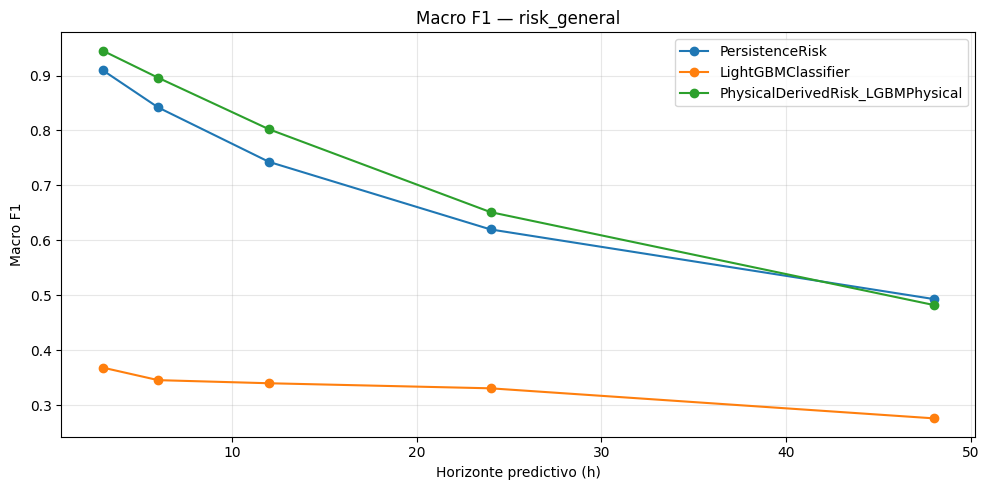

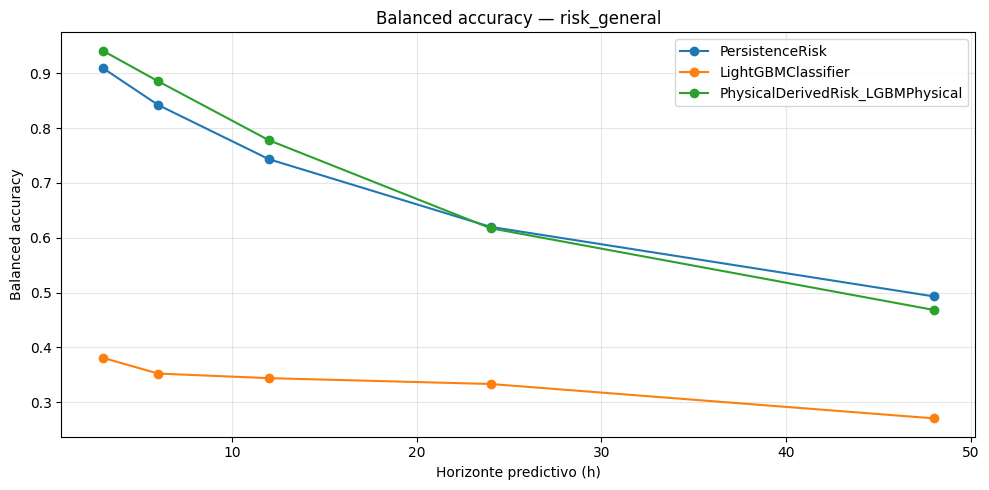

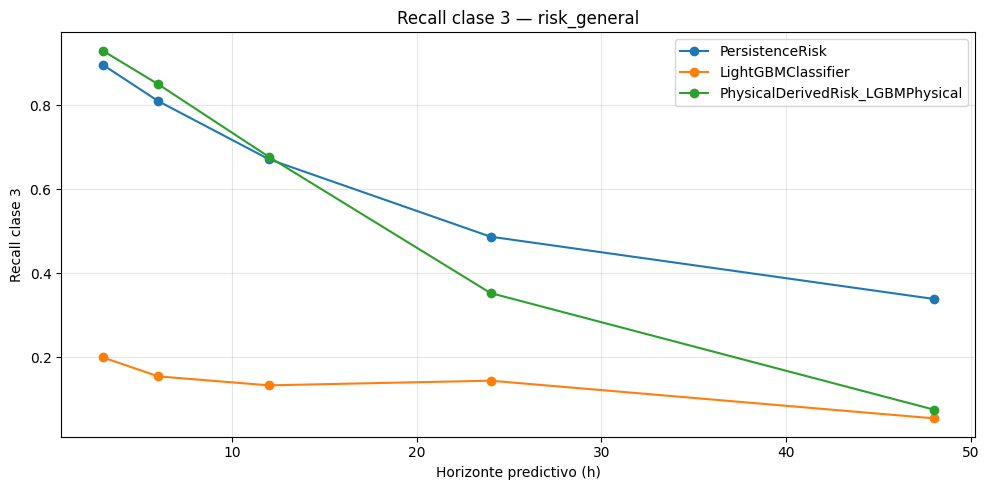

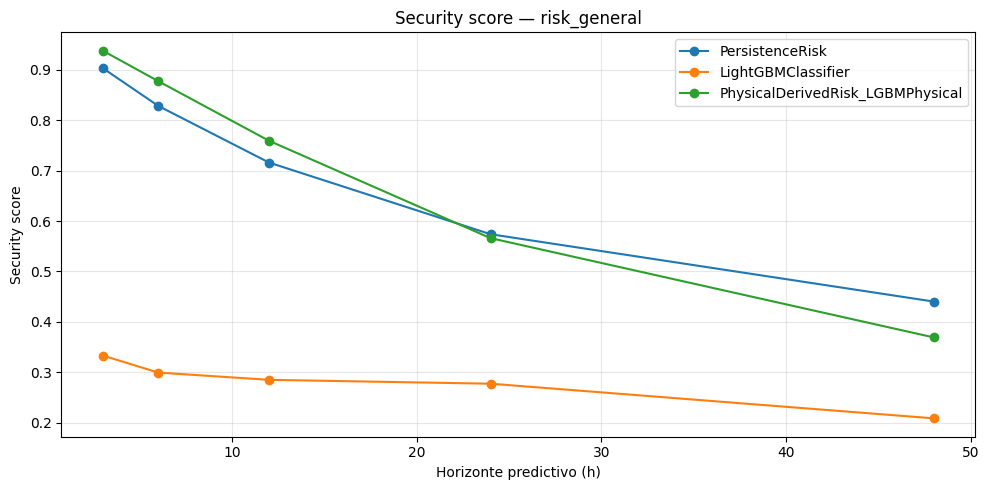

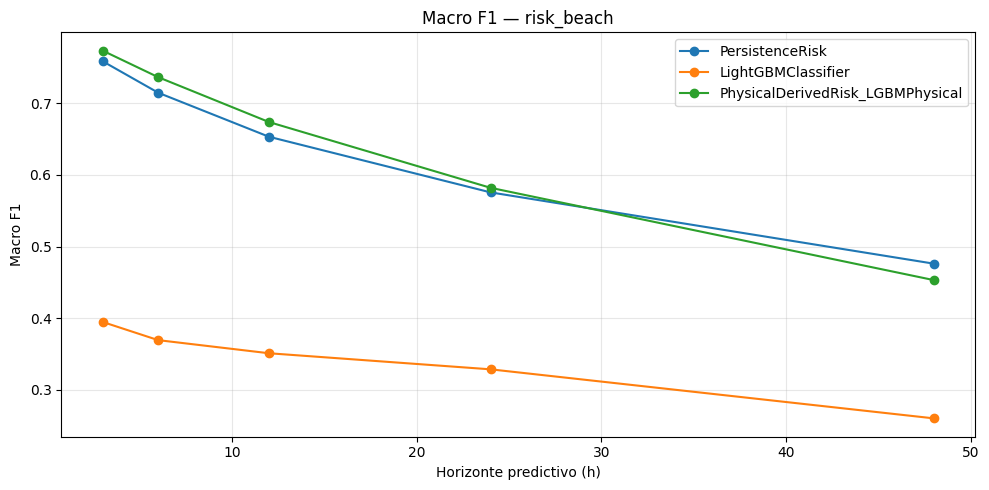

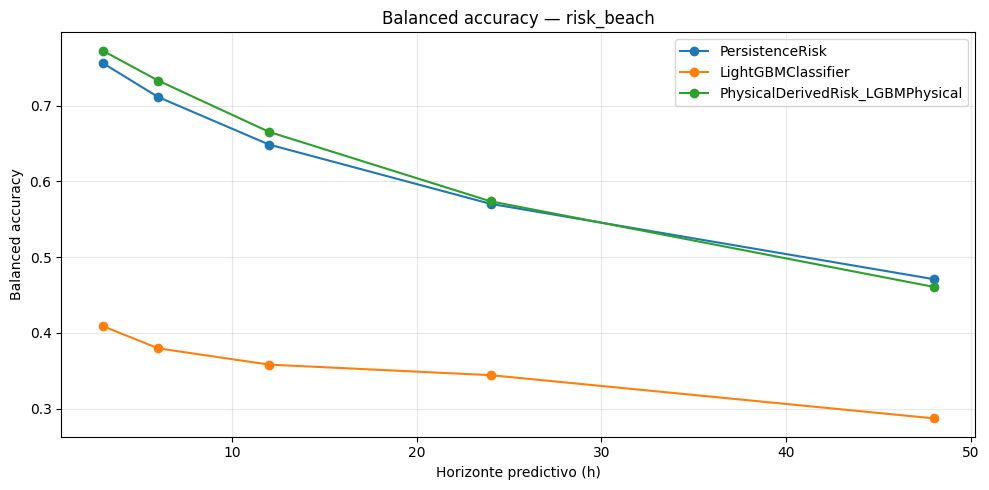

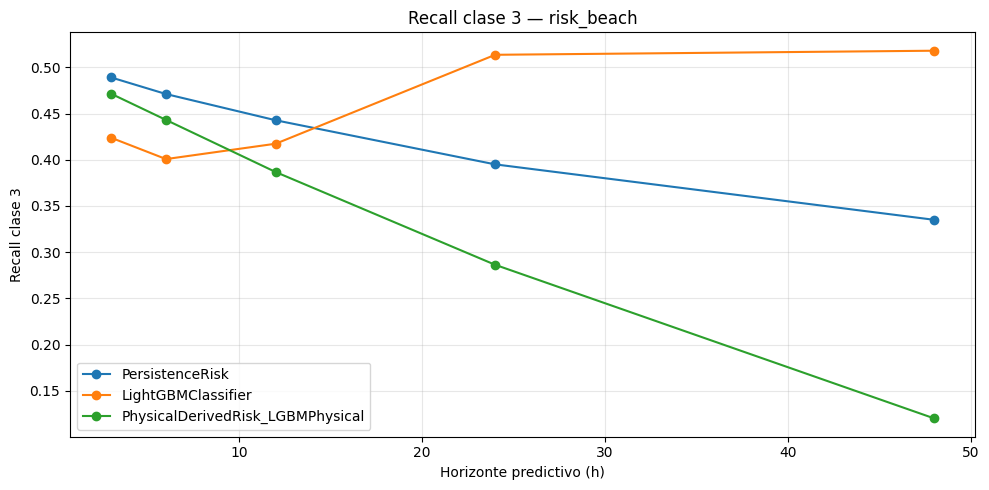

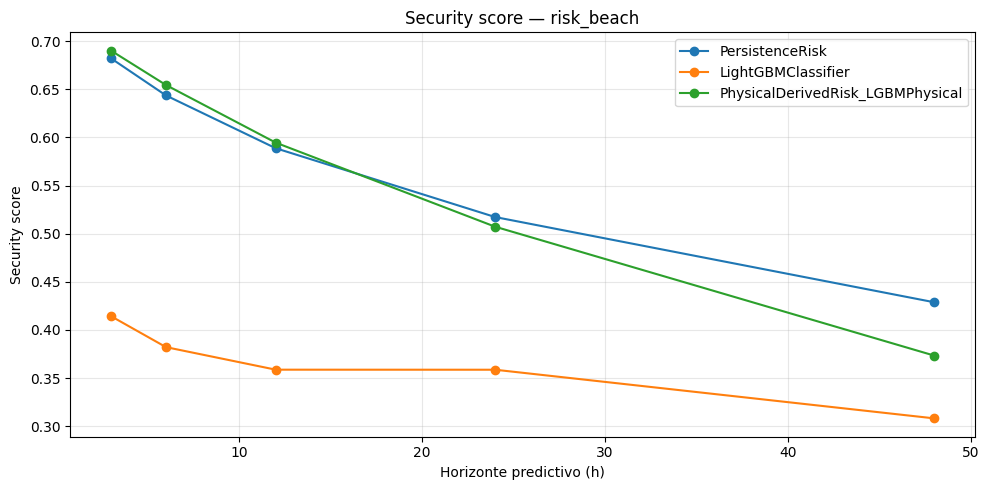

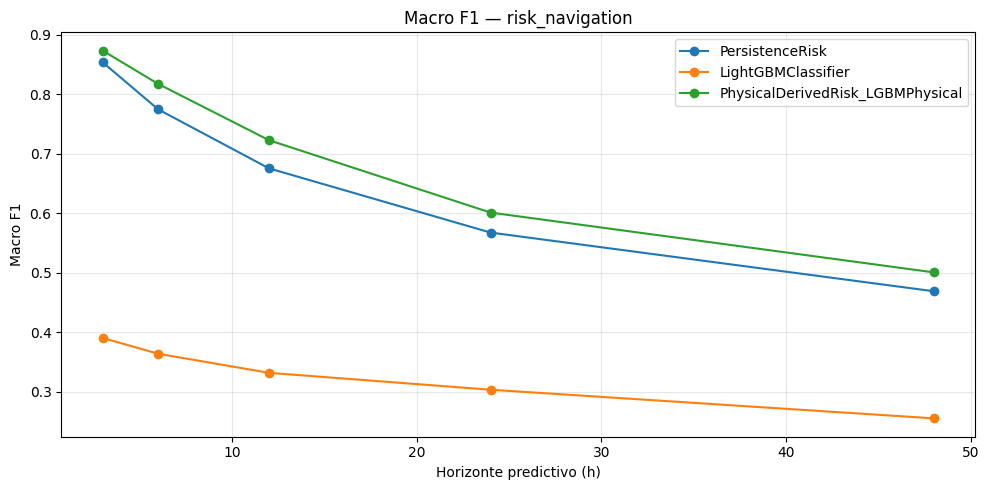

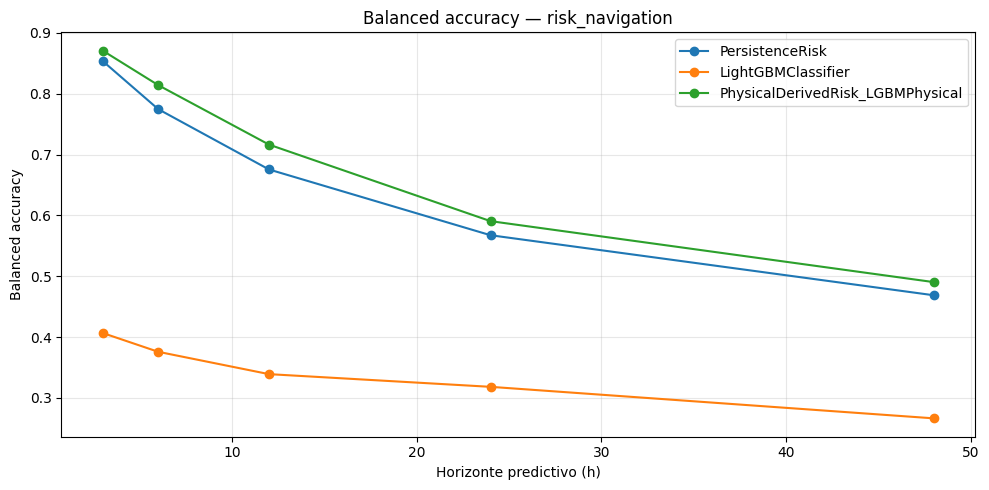

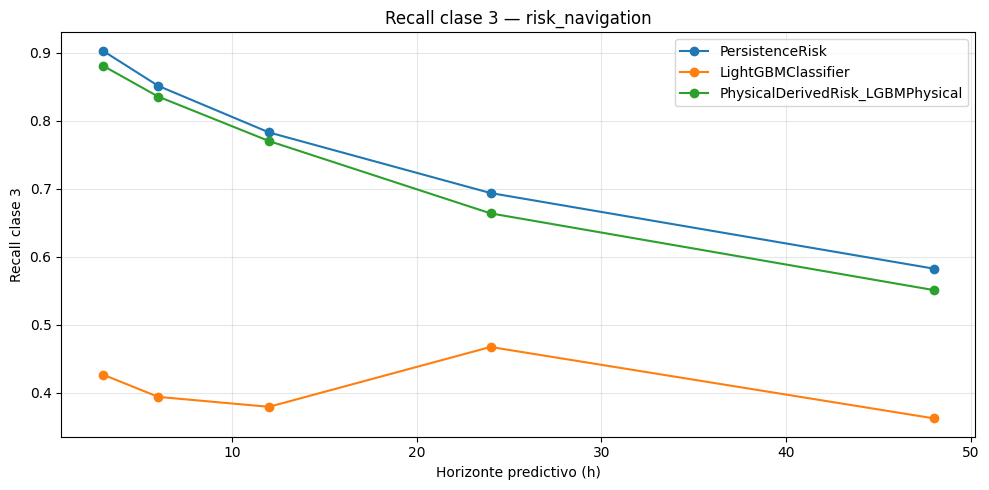

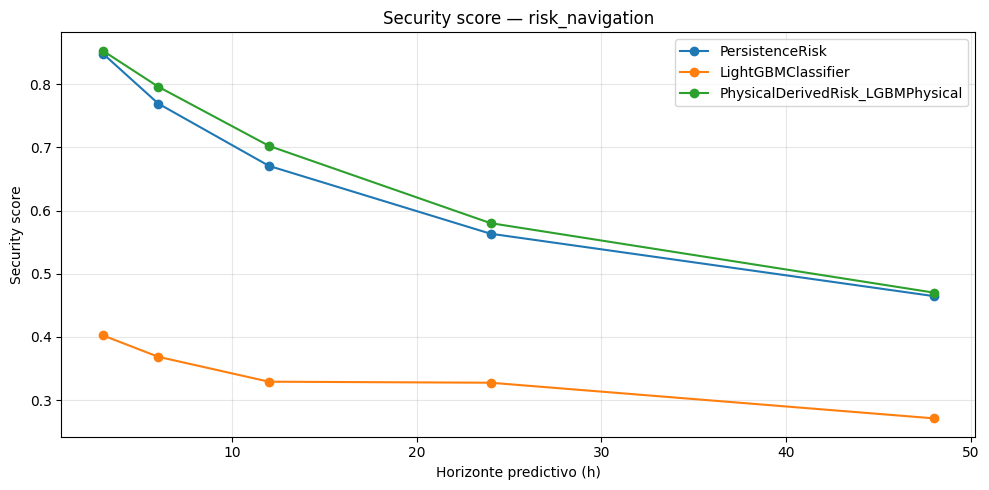

In [13]:
for module in RISK_MODULES:
    sub = test_scored[test_scored["risk_module"] == module].copy()
    if sub.empty:
        continue

    for metric, ylabel, filename_part in [
        ("macro_f1", "Macro F1", "macro_f1"),
        ("balanced_accuracy", "Balanced accuracy", "balanced_accuracy"),
        ("recall_class_3", "Recall clase 3", "recall_class_3"),
        ("security_score", "Security score", "security_score"),
    ]:
        plt.figure(figsize=(10, 5))
        for model_name in sub["model"].dropna().unique():
            data = sub[sub["model"] == model_name].sort_values("horizon_hours")
            plt.plot(data["horizon_hours"], data[metric], marker="o", label=model_name)

        plt.xlabel("Horizonte predictivo (h)")
        plt.ylabel(ylabel)
        plt.title(f"{ylabel} — risk_{module}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"plot_{filename_part}_risk_{module}.png", dpi=160)
        plt.show()

## Celda 13 — Top features por módulo

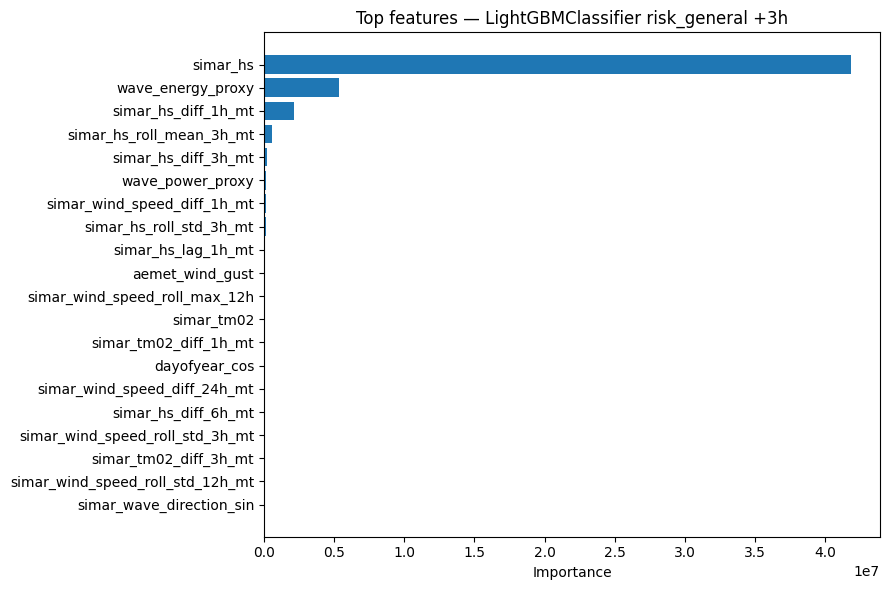

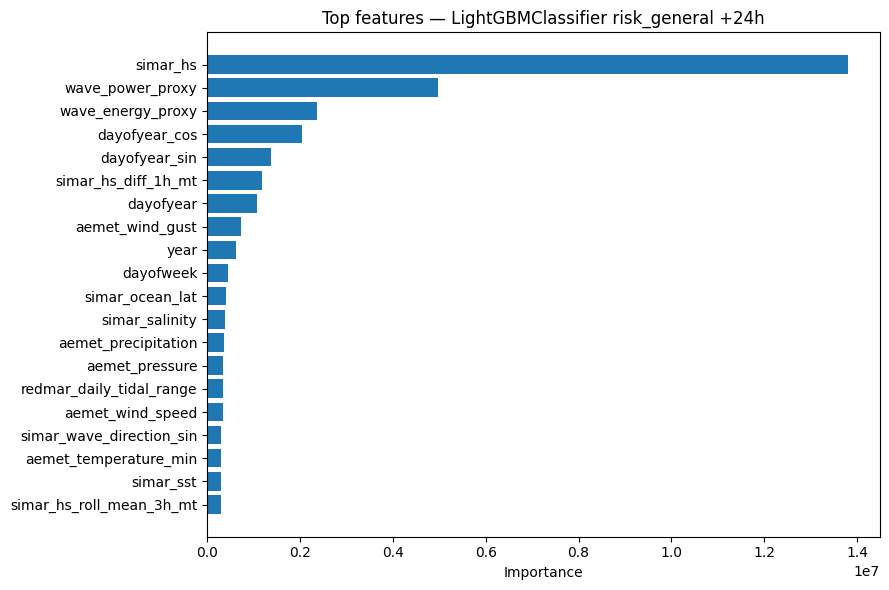

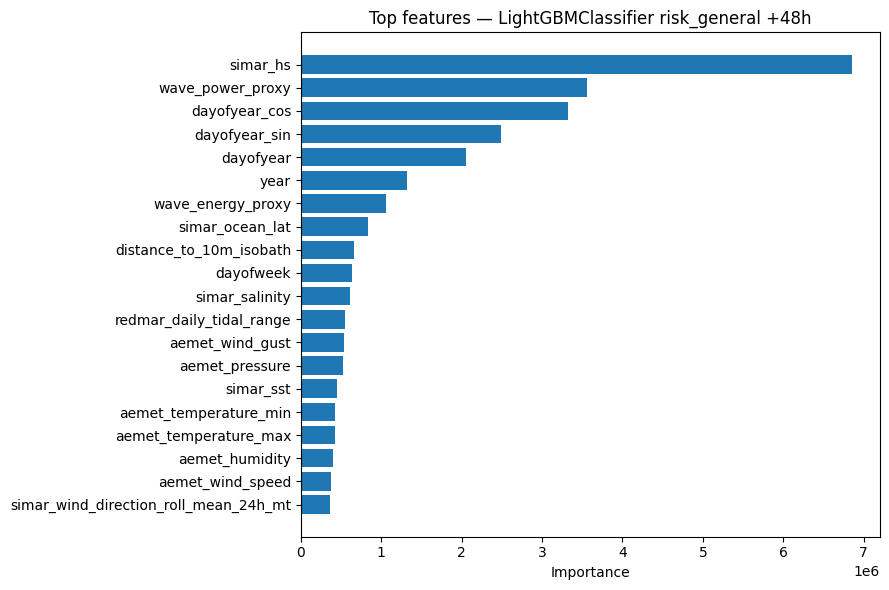

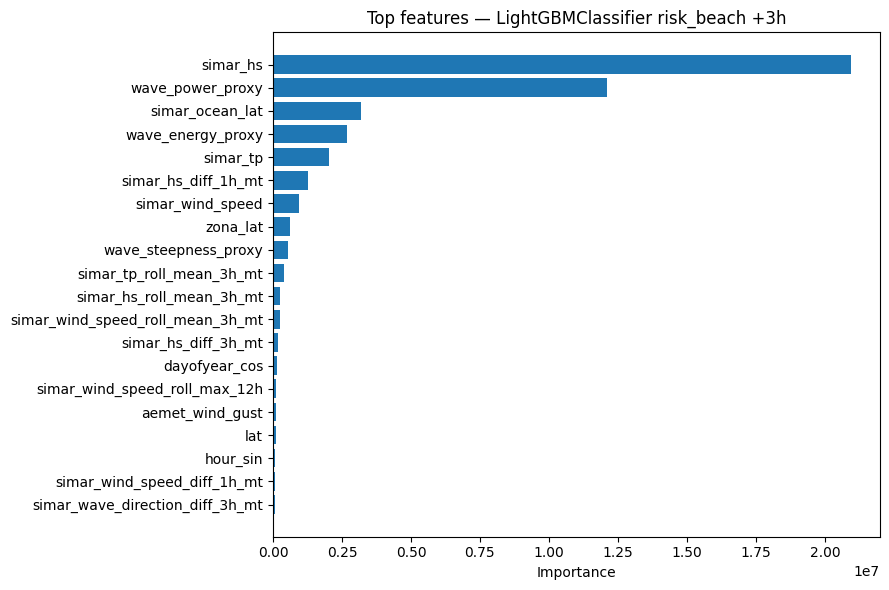

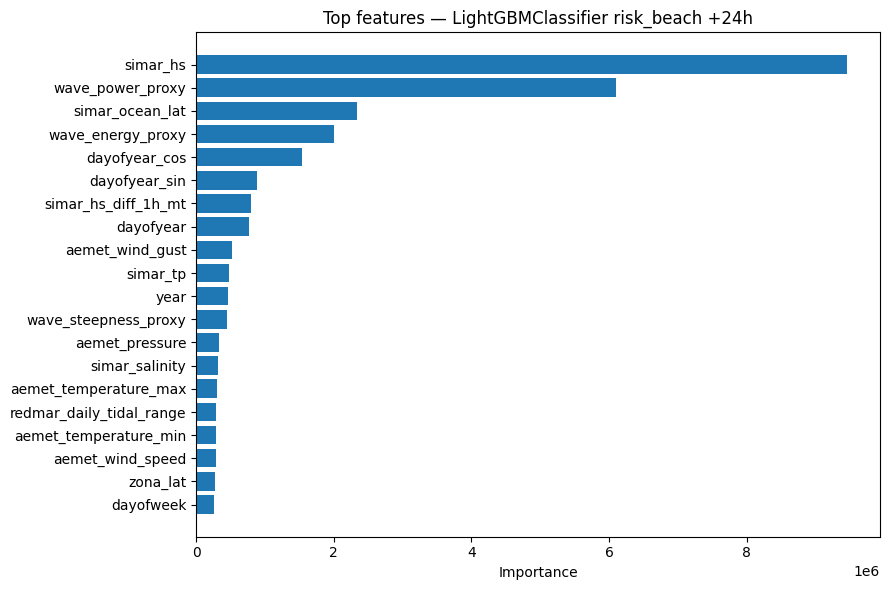

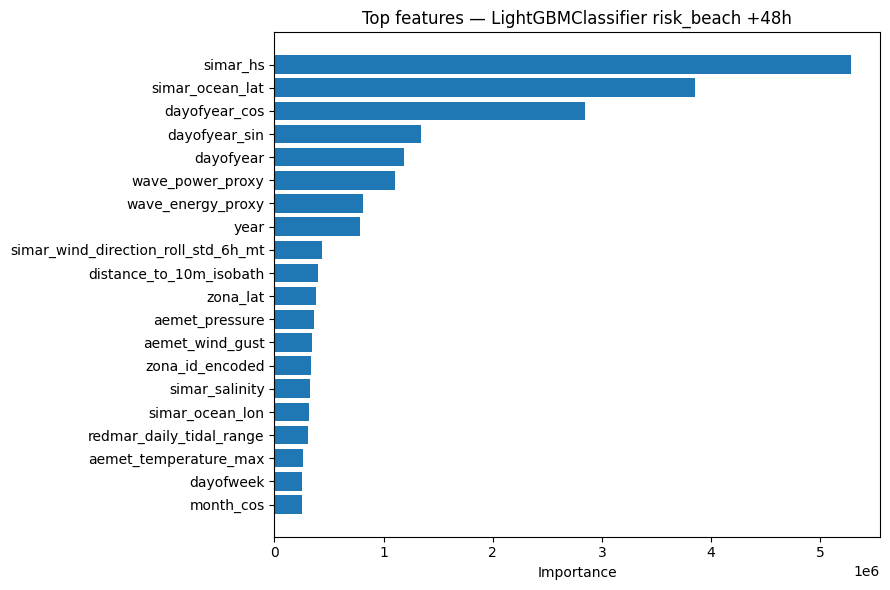

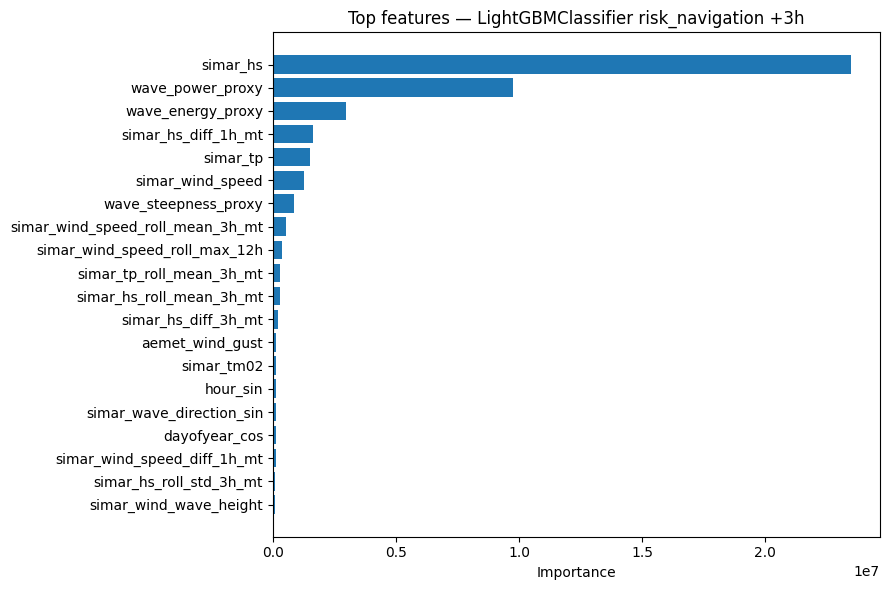

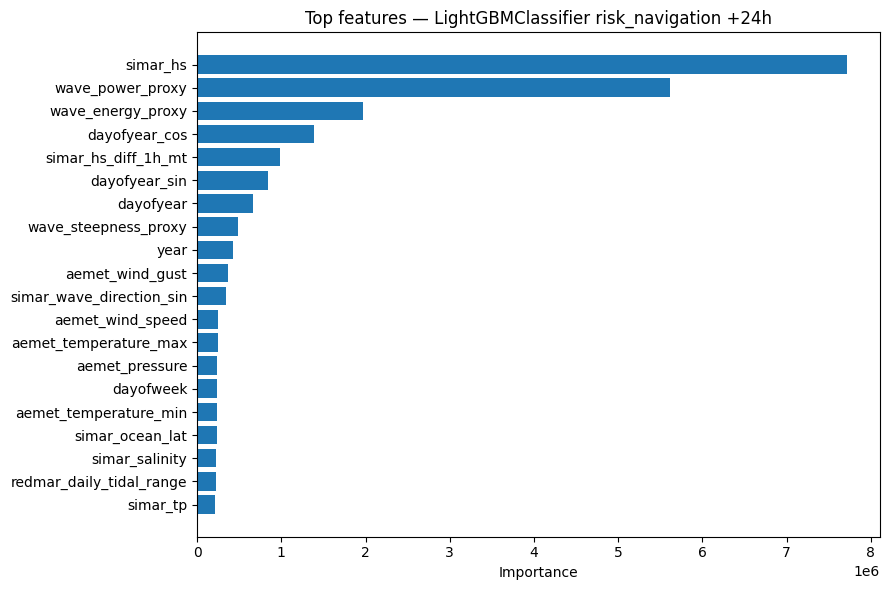

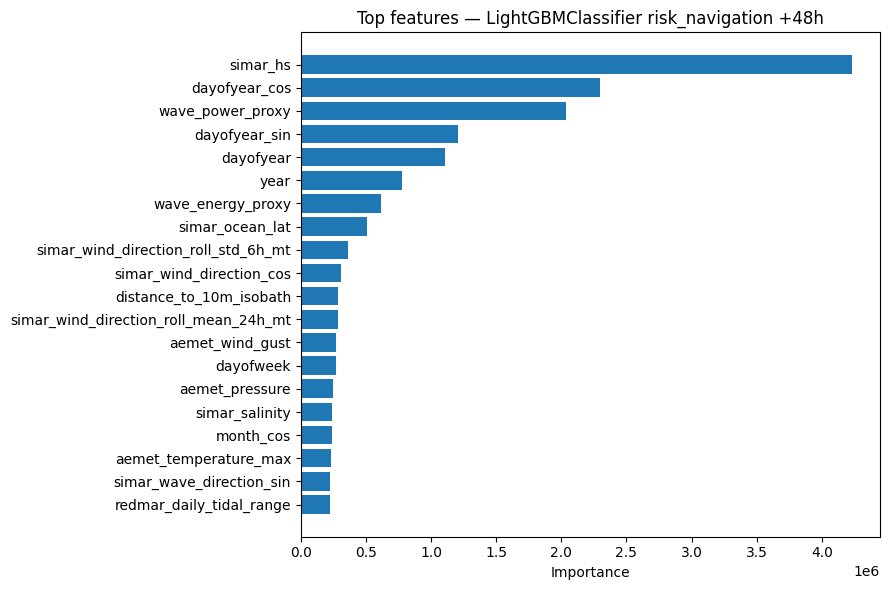

In [14]:
if not feature_importance_df.empty:
    for module in RISK_MODULES:
        for h in [3, 24, 48]:
            for model_name in ["LightGBMClassifier", "XGBClassifier"]:
                plot_df = (
                    feature_importance_df[
                        (feature_importance_df["risk_module"] == module)
                        & (feature_importance_df["horizon_hours"] == h)
                        & (feature_importance_df["model"] == model_name)
                    ]
                    .sort_values("importance_gain", ascending=False)
                    .head(20)
                    .sort_values("importance_gain", ascending=True)
                )

                if plot_df.empty:
                    continue

                plt.figure(figsize=(9, 6))
                plt.barh(plot_df["feature"], plot_df["importance_gain"])
                plt.xlabel("Importance")
                plt.title(f"Top features — {model_name} risk_{module} +{h}h")
                plt.tight_layout()
                plt.savefig(RESULTS_DIR / f"plot_top_features_{model_name}_{module}_{h}h.png", dpi=160)
                plt.show()

## Celda 14 — Informe ejecutivo

In [15]:
report_lines = []
report_lines.append("# Risk modules — DeepWave Canarias\n")
report_lines.append("## Dataset\n")
report_lines.append(f"- Entrada: `{INPUT_GOLD_DIR}`")
report_lines.append(f"- Filas: {len(gold):,}")
report_lines.append(f"- Columnas: {len(gold.columns):,}")
report_lines.append(f"- Features usadas: {len(encoded_feature_cols):,}")
report_lines.append(f"- Horizontes: {HORIZONS_HOURS}")
report_lines.append(f"- Módulos de riesgo: {RISK_MODULES}")
report_lines.append(f"- XGBoost entrenado: {TRAIN_XGBOOST and XGBOOST_AVAILABLE}")
report_lines.append("\n## Modelos entrenados\n")
report_lines.append(f"- Total modelos directos: {len(training_summary_df):,}")

if not training_summary_df.empty:
    for model_name, count in training_summary_df["model"].value_counts().items():
        report_lines.append(f"- {model_name}: {count}")

report_lines.append("\n## Recomendación por módulo y horizonte\n")

if not recommendation_df.empty:
    for module in RISK_MODULES:
        sub = recommendation_df[recommendation_df["risk_module"] == module].sort_values("horizon_hours")
        if sub.empty:
            continue
        report_lines.append(f"\n### risk_{module}\n")
        for _, row in sub.iterrows():
            report_lines.append(
                f"- +{int(row['horizon_hours'])}h: {row['recommended_model']} "
                f"(score={row['recommended_score']:.4f}, macro_f1={row['recommended_macro_f1']:.4f}, "
                f"balanced_acc={row['recommended_balanced_accuracy']:.4f}, "
                f"recall_c2={row['recommended_recall_class_2']:.4f}, "
                f"recall_c3={row['recommended_recall_class_3']:.4f})"
            )

report_md = "\n".join(report_lines)
(RESULTS_DIR / "risk_modules_report.md").write_text(report_md, encoding="utf-8")

summary_json = {
    "dataset": str(INPUT_GOLD_DIR),
    "results_dir": str(RESULTS_DIR),
    "models_dir": str(MODELS_DIR),
    "rows": int(len(gold)),
    "columns": int(len(gold.columns)),
    "feature_count": int(len(encoded_feature_cols)),
    "horizons_hours": HORIZONS_HOURS,
    "risk_modules": RISK_MODULES,
    "xgboost_available": XGBOOST_AVAILABLE,
    "train_xgboost": bool(TRAIN_XGBOOST and XGBOOST_AVAILABLE),
    "use_zona_id_as_feature": USE_ZONA_ID_AS_FEATURE,
    "models_trained": training_summary_df.to_dict(orient="records") if not training_summary_df.empty else [],
    "recommendations": recommendation_df.to_dict(orient="records") if not recommendation_df.empty else [],
}

save_json(summary_json, RESULTS_DIR / "risk_modules_summary.json")
save_json(summary_json, MODELS_DIR / "risk_modules_summary.json")

print(report_md[:4000])
print("\nInforme guardado:", RESULTS_DIR / "risk_modules_report.md")

# Risk modules — DeepWave Canarias

## Dataset

- Entrada: `/Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/multitarget_training_dataset`
- Filas: 983,328
- Columnas: 673
- Features usadas: 318
- Horizontes: [3, 6, 12, 24, 48]
- Módulos de riesgo: ['general', 'beach', 'navigation']
- XGBoost entrenado: False

## Modelos entrenados

- Total modelos directos: 15
- LightGBMClassifier: 15

## Recomendación por módulo y horizonte


### risk_general

- +3h: PhysicalDerivedRisk_LGBMPhysical (score=0.9375, macro_f1=0.9451, balanced_acc=0.9412, recall_c2=0.9260, recall_c3=0.9300)
- +6h: PhysicalDerivedRisk_LGBMPhysical (score=0.8772, macro_f1=0.8959, balanced_acc=0.8854, recall_c2=0.8651, recall_c3=0.8502)
- +12h: PhysicalDerivedRisk_LGBMPhysical (score=0.7591, macro_f1=0.8023, balanced_acc=0.7778, recall_c2=0.7637, recall_c3=0.6770)
- +24h: PersistenceRisk (score=0.5738, macro_f1=0.6201, balanced_acc=0.6198, recall_c2=0.5339, recall_c3=0.4871)
- +48h: PersistenceRis

## Celda 15 — Validación final

In [16]:
required_files = [
    RESULTS_DIR / "risk_target_inventory.csv",
    RESULTS_DIR / "feature_selection_audit.csv",
    RESULTS_DIR / "feature_metadata.json",
    RESULTS_DIR / "metrics_risk_classification.csv",
    RESULTS_DIR / "training_summary.csv",
    RESULTS_DIR / "feature_importance.csv",
    RESULTS_DIR / "test_metrics_risk_modules.csv",
    RESULTS_DIR / "test_metrics_risk_modules_scored.csv",
    RESULTS_DIR / "recommendation_by_risk_module_horizon.csv",
    RESULTS_DIR / "risk_modules_report.md",
    RESULTS_DIR / "risk_modules_summary.json",
    MODELS_DIR / "feature_metadata.json",
    MODELS_DIR / "risk_modules_summary.json",
]

missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError("Faltan archivos requeridos: " + json.dumps(missing, indent=2))

if training_summary_df.empty:
    raise ValueError("No se entrenó ningún modelo de riesgo.")

if test_scored.empty:
    raise ValueError("No hay métricas test.")

if test_scored["macro_f1"].isna().all():
    raise ValueError("Todas las métricas macro_f1 están nulas.")

model_files = list(MODELS_DIR.rglob("*.pkl"))

print("Modelos entrenados:")
display(training_summary_df)

print("\nRecomendaciones:")
display(recommendation_df)

print("\nArchivos principales:")
for p in required_files:
    print("-", p)

print("\nModelos guardados (.pkl):", len(model_files))
for p in model_files[:40]:
    print("-", p)
if len(model_files) > 40:
    print("...")

print("\n✅ Entrenamiento de módulos de riesgo completado correctamente.")

Modelos entrenados:


,risk_module,horizon_hours,model,target_col,train_rows,val_rows,test_rows,classes_train,weights_by_class,best_iteration,model_path
0,general,3,LightGBMClassifier,target_risk_general_3h,698181,87300,197043,"[0, 1, 2, 3]","{""0"": 1.4255457730662116, ""1"": 0.5406177280954...",1170,/Users/rauljimenez/Development/Projects/AI-Pro...
1,general,6,LightGBMClassifier,target_risk_general_6h,697650,87240,196830,"[0, 1, 2, 3]","{""0"": 1.4252764135293492, ""1"": 0.5406186238069...",1486,/Users/rauljimenez/Development/Projects/AI-Pro...
2,general,12,LightGBMClassifier,target_risk_general_12h,696588,87120,196404,"[0, 1, 2, 3]","{""0"": 1.424713457086057, ""1"": 0.54065252779944...",1605,/Users/rauljimenez/Development/Projects/AI-Pro...
3,general,24,LightGBMClassifier,target_risk_general_24h,694464,86880,195552,"[0, 1, 2, 3]","{""0"": 1.4237588361680142, ""1"": 0.5409667901278...",1204,/Users/rauljimenez/Development/Projects/AI-Pro...
4,general,48,LightGBMClassifier,target_risk_general_48h,690456,86400,193848,"[0, 1, 2, 3]","{""0"": 1.4228695781195906, ""1"": 0.5417935134161...",965,/Users/rauljimenez/Development/Projects/AI-Pro...
5,beach,3,LightGBMClassifier,target_risk_beach_3h,698181,87300,197043,"[0, 1, 2, 3]","{""0"": 1.4255457730662116, ""1"": 0.7577064160444...",1475,/Users/rauljimenez/Development/Projects/AI-Pro...
6,beach,6,LightGBMClassifier,target_risk_beach_6h,697650,87240,196830,"[0, 1, 2, 3]","{""0"": 1.4252764135293492, ""1"": 0.7577479807176...",1706,/Users/rauljimenez/Development/Projects/AI-Pro...
7,beach,12,LightGBMClassifier,target_risk_beach_12h,696588,87120,196404,"[0, 1, 2, 3]","{""0"": 1.424713457086057, ""1"": 0.75782271094982...",1481,/Users/rauljimenez/Development/Projects/AI-Pro...
8,beach,24,LightGBMClassifier,target_risk_beach_24h,694464,86880,195552,"[0, 1, 2, 3]","{""0"": 1.4237588361680142, ""1"": 0.7578865856111...",794,/Users/rauljimenez/Development/Projects/AI-Pro...
9,beach,48,LightGBMClassifier,target_risk_beach_48h,690456,86400,193848,"[0, 1, 2, 3]","{""0"": 1.4228695781195906, ""1"": 0.7586761603375...",284,/Users/rauljimenez/Development/Projects/AI-Pro...



Recomendaciones:


,risk_module,horizon_hours,recommended_model,recommended_score,recommended_macro_f1,recommended_balanced_accuracy,recommended_recall_class_2,recommended_recall_class_3,all_models_ranked
0,beach,3,PhysicalDerivedRisk_LGBMPhysical,0.690130,0.773451,0.772548,0.722981,0.471353,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
1,beach,6,PhysicalDerivedRisk_LGBMPhysical,0.654465,0.736513,0.733088,0.684337,0.443052,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
2,beach,12,PhysicalDerivedRisk_LGBMPhysical,0.594626,0.673901,0.665428,0.638285,0.386644,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
3,beach,24,PersistenceRisk,0.517329,0.575733,0.570415,0.496512,0.394968,"[{""model"": ""PersistenceRisk"", ""security_score""..."
4,beach,48,PersistenceRisk,0.428847,0.476285,0.471018,0.404267,0.335009,"[{""model"": ""PersistenceRisk"", ""security_score""..."
5,general,3,PhysicalDerivedRisk_LGBMPhysical,0.937471,0.945097,0.941164,0.926040,0.929959,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
6,general,6,PhysicalDerivedRisk_LGBMPhysical,0.877195,0.895858,0.885385,0.865059,0.850159,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
7,general,12,PhysicalDerivedRisk_LGBMPhysical,0.759051,0.802272,0.777760,0.763689,0.677050,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
8,general,24,PersistenceRisk,0.573849,0.620085,0.619793,0.533913,0.487135,"[{""model"": ""PersistenceRisk"", ""security_score""..."
9,general,48,PersistenceRisk,0.440417,0.493495,0.492963,0.398100,0.338950,"[{""model"": ""PersistenceRisk"", ""security_score""..."



Archivos principales:
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/risk_modules/risk_target_inventory.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/risk_modules/feature_selection_audit.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/risk_modules/feature_metadata.json
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/risk_modules/metrics_risk_classification.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/risk_modules/training_summary.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/risk_modules/feature_importance.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/risk_modules/test_metrics_risk_modules.csv
- /Users/rauljimenez/Development/Projects/AI-Projects/deep-w

## Resultado esperado

Al final debe aparecer:

```text
✅ Entrenamiento de módulos de riesgo completado correctamente.
```

Salidas principales:

```text
models/risk_modules/
gold/model_results/risk_modules/
```

Archivos clave:

```text
metrics_risk_classification.csv
metrics_risk_classification_with_physical_derived.csv
metrics_physical_derived_risk.csv
test_metrics_risk_modules.csv
test_metrics_risk_modules_scored.csv
recommendation_by_risk_module_horizon.csv
predictions_val_test_risk_modules.parquet
feature_importance.csv
feature_importance_top30.csv
risk_modules_report.md
risk_modules_summary.json
```